In [9]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install --upgrade scipy


Note: you may need to restart the kernel to use updated packages.


## SciPy's Relationship with NumPy.

- NumPy is the core library for numerical operations in Python. It provides arrays, broadcasting, and fundamental linear algebra operations.
- SciPy is built on top of NumPy. It adds advanced algorithms like integration, optimization, root finding, and solving differential equations.
- When solving matrix differential equations, NumPy handles data representation (arrays) and basic math, while SciPy provides solvers like solve_ivp.
- SciPy functions usually accept and return NumPy arrays, meaning both libraries work hand-in-hand.
- Understanding this relationship helps you use both libraries efficiently when solving complex scientific problems.

## Examples of SciPy's Relationship with NumPy.

## Example 1: NumPy Array creation, used with SciPy solver.

In [2]:
# Import required libraries
import numpy as np
from scipy.integrate import solve_ivp

# Define the system of ODEs
def dX_dt(t, X):
    # Define matrix A for rotation
    A = np.array([[0, -1],
                  [1,  0]])
    # Perform matrix-vector multiplication: dX/dt = A * X
    # Note: X is already a 1D array, shape (2,)
    return A @ X  # returns a 1D array, shape (2,)

# Initial condition: vector X0 = [1.0, 0.0]
X0 = np.array([1.0, 0.0])

# Solve the differential equation from t = 0 to t = 10
sol = solve_ivp(dX_dt, [0, 10], X0)

# Print the solution at all time steps
print(sol.y)  # sol.y contains the solution vectors at all times in sol.t


[[ 1.00000000e+00  9.99999501e-01  9.99939621e-01  9.93858100e-01
   7.24709764e-01 -1.22607648e-01 -8.96412983e-01 -8.66881284e-01
  -1.33005579e-01  7.61809510e-01  9.67792753e-01  3.37808419e-01
  -6.01037671e-01 -9.99858424e-01 -8.37545242e-01]
 [ 0.00000000e+00  9.99000833e-04  1.09887898e-02  1.10661995e-01
   6.89037713e-01  9.92423098e-01  4.43138753e-01 -4.98428062e-01
  -9.91048308e-01 -6.47700170e-01  2.51430149e-01  9.41118675e-01
   7.99102741e-01 -7.31642727e-03 -5.46146478e-01]]


## Example 2: Using NumPy functions inside SciPy Differential Equation.

- In SciPy, a differential equation is a mathematical equation that relates a function with its derivatives, and SciPy provides tools to solve these equations numerically using functions in the scipy.integrate module.

- Differential Equations describe how things change — like how a population grows, how heat spreads, or how a pendulum swings.

- In SciPy, solving a differential equation means finding the function (like x(t)) that satisfies a rate of change rule, often written as:

- dy/dt = f(t, y)

- SciPy doesn't solve them symbolically like SymPy — instead, it computes numerical solutions (approximate values of y(t) at time points).

- The main function used for this is solve_ivp() (solve initial value problem), which lets you specify:
- A function for the derivative i.e. f(t,y).
- An interval of time.

- SciPy supports systems of differential equations (multiple equations with multiple variables), making it suitable for real-world physics, biology, and engineering problems.

- We can do these things in Differential Equations in SciPy:
- solve_ivp: Solves ODEs numerically with various methods (RK45, RK23, etc.)
-  Handles Systems: You can solve equations like dx/dt = x + y, dy/dt = x- y.
- Time-dependent functions: Support for equations where coefficients change over time.
- Custom Models: Good for scientific simulations like disease spread, circuits, etc.
 



In [3]:
import numpy as np
from scipy.integrate import solve_ivp

# Define time-dependent system of ODEs
def dX_dt(t, X):
    # Time-varying matrix A using sin(t) and exp(-t)
    A = np.array([[np.sin(t), 1],
                  [0, np.exp(-t)]])
    # Multiply 2x2 matrix with 2x1 vector (no reshaping needed)
    return A @ X  # Result is 1D array of length 2 (shape = (2,))

# Initial condition
X0 = np.array([1, 0])  # Starting at x=1, y=0

# Solve the ODE system from t = 0 to t = 5
sol = solve_ivp(dX_dt, [0, 5], X0)

# Print the resulting solution vectors
print(sol.y)  # sol.y[0] is x(t), sol.y[1] is y(t)


[[1.         1.         1.00000061 1.00006161 1.0061843  1.74444847
  5.78885709 7.10806906 3.63152064 2.04739461]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]


## Example 3: Matrix Exponential using NumPy and SciPy.

- The matrix exponential is a mathematical function that generalizes the exponential function to square matrices.

- It is important in solving systems of linear differential equations, especially in physics, control systems, and engineering.

- SciPy provides a convenient and efficient way to compute this using scipy.linalg.expm.

- The matrix exponential is a way to extend the idea of the exponential function (like e^x to square matrices. It is not just about taking e to the power of each matrix element — instead, it’s about how a matrix transforms over time, especially in systems of linear differential equations.

- Used in Solving Linear ODEs: If you have a system like dx/dt = Ax, then the solution is x(t) = e^atx(0). You can compute e^At with scipy.linalg.expm.

- It Handles Any Square Matrix: Works for 2×2, 3×3, 10×10, or any Square Matrix.

- Diagonal Matrix Simplicity: If the Matrix is Diagonal, it just applies the Exponential to each Diagonal Element — very efficient.

- Matrix Exponential is similar to the Exponential of a Number, but it is applied to a Square Matrix instead of a scalar.

- Matrix Exponential is similar to the Exponential of a number, but it is applied to a square matrix instead of a scalar i.e. from scipy.linalg import expm , where expm(A) gives e^A, the matrix exponential of A.

- It is defined using a Power Series: e^A = I + A + A^2/2! + A^3/3! + ..........

- The matrix exponential is not the same as taking np.exp(A), which does element-wise exponentiation. expm(A) applies true matrix exponential logic.

- It is most commonly used in solving systems of linear ODEs of the form: dx/ dt = AX ⇒ X(t) = e^At X(0).

- It plays a central role in linear algebra, especially in modeling dynamic systems, like population growth or electrical circuits.

- The Exponential of a diagonal matrix is easy to compute: just take the exponential of each diagonal element.

- SciPy's epm works with both real and complex matrices and is highly optimized.





In [4]:
# Define a rotation matrix A which gives dX/dt = A*X.

def dX_dt(t, X):
    A = np.array([[0, -1], [1, 0]])  # Rotation in 2D
    return (A @ X.reshape(2, 1)).flatten()  # Matrix multiplication and flatten to 1D

X0 = np.array([1, 0])  # Initial vector
sol = solve_ivp(dX_dt, [0, 2*np.pi], X0)  # Integrate over one full circle (0 to 2π)
print(sol.y)  # Output the computed solution


[[ 1.00000000e+00  9.99999501e-01  9.99939621e-01  9.93858100e-01
   7.24709764e-01 -1.22607648e-01 -8.96412983e-01 -8.66881284e-01
  -1.33005579e-01  7.61809510e-01  9.99917327e-01]
 [ 0.00000000e+00  9.99000833e-04  1.09887898e-02  1.10661995e-01
   6.89037713e-01  9.92423098e-01  4.43138753e-01 -4.98428062e-01
  -9.91048308e-01 -6.47700170e-01  1.50164054e-03]]


## Example 4: NumPy Broadcasting inside SciPy ODE.

- NumPy Broadcasting inside SciPy allows arrays of different shapes to be used together in mathematical operations as if they had the same shape — without copying data.

- Instead of manually reshaping or repeating arrays to match dimensions, broadcasting automatically stretches smaller arrays along the mismatched dimensions.

- Broadcasting is Important due to these reasons:
1) Saves memory.
2) Speeds up Matrix Calculations.
3) Makes code simpler and cleaner.
4) Allows element-wise operations without manual looping.

- ODE stands for Ordinary Differential Equation. SciPy provides tools to solve ODEs numerically using functions like solve_ivp().

- In simple terms, an ODE is an equation that describes how something changes over time(like velocity, population, temperature, etc.).

- ODEs Describe Changing Systems: An ODE models how variables evolve over time. For example, in physics i.e. dx/dt = Velocity and dy/dt = Function of Time or State.

- SciPy Uses solve_ivp() Function: SciPy's scipy.integrate.solve_ivp() solves ODEs numerically between two time points.

- You Must Define a Function for the Derivative: The ODE system must be written as a Python function that returns the rate of change (derivative) i.e.

-  def dy_dt(t, y):
    return -2 * y


- def dy_dt(t, y):
    return -2 * y

- Set an Initial Condition: You must specify the initial value of the variable at the start time i.e. y0 = [1]  # y(0) = 1

- Choose the Time Interval for the Solution: Tell SciPy how long to integrate: from time t0 to t1 i.e. solution = solve_ivp(dy_dt, [0, 5], y0)



## Example 1 : Solve dy/dt = -2y, where y(0) = 1.

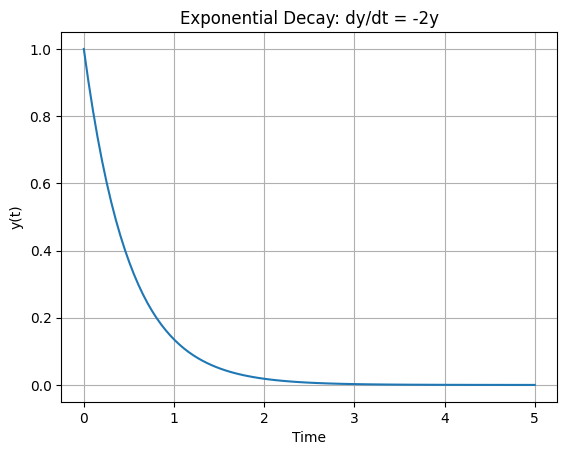

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def dy_dt(t, y):
    return -2 * y

sol = solve_ivp(dy_dt, [0, 5], [1], t_eval=np.linspace(0, 5, 100))

plt.plot(sol.t, sol.y[0])
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Exponential Decay: dy/dt = -2y")
plt.grid()
plt.show()


## Example 2: Automatic Dimension Matching.

- If two Arrays don’t have the Same Shape, NumPy/SciPy will try to Automatically align them using Broadcasting Rules.

In [7]:
import numpy as np
A = np.array([[1, 2], [3, 4]])  # Shape: (2, 2)
B = np.array([10, 20])          # Shape: (2,)
print(A + B)  # B is broadcasted to match shape (2, 2)


[[11 22]
 [13 24]]


## Example 5: NumPy Dot Product inside SciPy Model.

- The Dot Product is a way to Multiply Two Arrays or Matrices. It’s used for things like Vector Projection, angles between Vectors, and Matrix Multiplication in Mathematics, Physics, Machine Learning, and Engineering.

- The Dot Product is a way to Multiply two Arrays or Matrices. It’s used for things like Vector Projection, Angles between Vectors, and Matrix Multiplication in Mathematics, Physics, Machine Learning, and Engineering.

-  In SciPy, a model usually refers to a mathematical or scientific formula, equation, or system that can be simulated, optimized, or solved using SciPy's tools.

- The Dot Product is done using numpy.dot() or the @ operator in Python.

- It Multiplies two Arrays: for Vectors, it gives a Single Number; for Matrices, it gives another Matrix or Vector.

- In SciPy Models, Dot Product is used to describe Linear Systems, like Ax = b.

- It’s useful in ODEs (Ordinary Differential Equations) where the System is represented using Matrix Equations.

- SciPy doesn't define its own dot product — it uses NumPy’s functions internally.

- Dot Products are faster than loops and optimized using NumPy under the hood.

- Works great in Machine Learning Models, Physics Simulations, Economics, and Engineering Models.

- You can use dot() in combination with solve_ivp, curve_fit, and other SciPy tools.

- You can Reshape arrays (reshape()) before applying the Dot Product to make them Compatible.

- Dot product lets you write compact and efficient model code.

- It’s often used when working with state vectors and matrices of coefficients.

- The Dot Product is a way to Multiply Matrices or Vectors to combine them Mathematically. In SciPy Models, it’s often used to define Systems like Differential Equations, Curve Fitting, or Physical Simulations where Matrix Operations are involved.






## Example 1: Dot Product in a SciPy ODE Model (Rotation System).

- We are solving a System of Differential Equations that describe Rotation in 2D Space using Matrix Multiplication (Dot Product) inside SciPy’s solve_ivp function.

- Ordinary Differential Equations (ODEs) describe how things change over time. We’re solving an equation of the form:

- dX/dt = A.X, where, X is a 2D Vector (like a point in space:[x,y]) and A is a matrix that defines how X changes. 

- The Matrix A =  [[0, -1], [1, 0]] is a special matrix. It performs a 90° counter-clockwise rotation of any 2D vector.

- By using dx/dt = A @ X, we say that the rate of change of X is always perpendicular to X, which is the property of circular motion.

- As time passes, the vector X(t) moves around a circle — like an object in uniform circular motion.

- The solve_ivp() function is a powerful tool in SciPy to numerically solve ODEs step by step.

- Inside the function we define(rotation_model), we compute the Dot Product, A @ X, which gives us the next value of dX/dt.

- The Dot Product in this context is used for Matrix-Vector Multiplication (2×2 Matrix × 2×1 Vector).

- This model assumes no external forces or damping — just pure rotation at unit speed.

- The initial condition X0 = [1, 0] means the object starts on the x-axis.

- The result is a trajectory of the point moving in a circle around the origin.

- We can visualize it using matplotlib to see the point spinning around the origin in 2D.





In [ ]:
import numpy as np # Used for Creating and Manipulating Matrices and Vectors.
# solve_ivp stands for "Solve Initial Value Problem" and is a function in the scipy.integrate module. It is used to Solve Systems of Ordinary Differential Equations (ODEs) numerically.
# solve_ivp from scipy.integrate: Solves Systems of Ordinary Differential Equations (ODEs) using Numerical Methods.
from scipy.integrate import solve_ivp  
import matplotlib.pyplot as plt #  Used to plot the Final Solution in 2D.

# Define the rotation system as a function (ODE model)
# This Function models Circular Rotation i.e. This means the function simulates how a point moves in a circle over time — like how the tip of a clock’s second hand moves around the clock face.
# A is a rotation generator matrix for 90° Counterclockwise Rotation.
# The Equation dX/dt = A @ X causes the state vector X to rotate over time i.e.
#1) X is just a point, like [1, 0].
#2) The equation means: “how fast the point moves (dX/dt) depends on multiplying it with matrix A.”
#3) The result is that the point keeps changing direction in a way that follows a circular path.
# @ is the Dot Product Operator i.e. Matrix Multiplication.
# The @ symbol in Python is used to do Matrix Multiplication means you’re multiplying the matrix A by the vector X.
# This is not the same as Normal Multiplication — it's a special rule for Combining Numbers that represent positions or directions.
# This represents a first-order linear ODE System i.e. 
#) Let’s break this into two parts:
#1) First-order: means the equation only looks at the first derivative — or how fast the position is changing.
#2) Linear ODE: means the rate of change is directly proportional to the position — there's no square roots, powers, or weird functions.

def rotation_model(t, X):
    A = np.array([[0, -1], [1, 0]])  # Rotation matrix (90-degree counterclockwise)
    return A @ X  # Matrix-vector multiplication using dot product

# Initial condition: the point starts at (1, 0).
# This code simulates circular motion using a system of ordinary differential equations (ODEs).
# The vector X = [x, y] represents a point in 2D space.
# The function rotation_model defines how this point moves at any moment.
# It uses a matrix A = [[0, -1], [1, 0]] which represents a 90° counterclockwise rotation.
# The equation dX/dt = A @ X means the velocity of the point is perpendicular to its position.
#This causes the point to rotate around the origin in a circle.
# solve_ivp numerically solves this equation from t = 0 to t = 10.
# The solution is evaluated at 200 time points using np.linspace.
# The output sol.y[0] and sol.y[1] contain the x and y positions over time.
# The result is plotted with matplotlib showing a perfect circular path.
# The @ operator is used for matrix-vector multiplication (dot product).
# This is a common approach for modeling 2D rotational dynamics in physics and simulations.

X0 = [1, 0]

# Solve the ODE system from time t = 0 to t = 10 with 200 steps
sol = solve_ivp(rotation_model, [0, 10], X0, t_eval=np.linspace(0, 10, 200))

# Plot the x(t) vs y(t) to visualize the trajectory (should be circular)
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x(t)')  # Label for x-axis
plt.ylabel('y(t)')  # Label for y-axis
plt.title('2D Rotation using ODE and Dot Product')  # Title of the plot
plt.gca().set_aspect('equal')  # Equal scaling on both axes to preserve circle
plt.grid(True)  # Add grid lines to the plot
plt.show()  # Display the plot


## Example 1: Simple 2D Dot Product.

In [1]:
import numpy as np
a = np.array([1, 2])
b = np.array([3, 4])
print(np.dot(a, b))  # Output: 1*3 + 2*4 = 11


11


## Example 2: Dot Product of Matrix and Vector.

In [2]:
A = np.array([[2, 0], [0, 3]])
v = np.array([1, 2])
print(A @ v)  # Output: [2*1 + 0*2, 0*1 + 3*2] = [2, 6]


[2 6]


## Example 3: Dot Product to find Angle between Vectors.


In [6]:
a = np.array([1, 0])
b = np.array([2, 2])
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print("Cosine of angle:", cos_theta)  # Should be 0


Cosine of angle: 0.7071067811865475


## Example 6: NumPy Reshape used inside SciPy ODE.

- SciPy ODE Functions Use Flat Arrays: SciPy's ODE solver functions like solve_ivp pass the state variable X as a 1D NumPy Array, even when the Actual system is Matrix-Based or Multi-Dimensional.

- NumPy reshape() Fixes Dimensions: The reshape() Method is used inside the ODE Function to convert a Flat Vector (like [x1, x2]) into a Matrix or Column Vector (like [[x1], [x2]]) for Matrix Operations.

- Why It's Needed:When solving Matrix-Vector ODEs(e.g., dx/dt = A @ X), reshaping ensures proper matrix multiplication. Otherwise, Python throws errors or gives incorrect shapes.

- Example Use Case – Matrix System: A 2D Linear System like a Rotation or Scaling Model uses reshape(2, 1) to turn [x, y] into a column matrix before multiplying it with a 2×2 matrix A.

- reshape(2, 1) to turn [x, y] into a column matrix before multiplying it with a 2×2 matrix A.



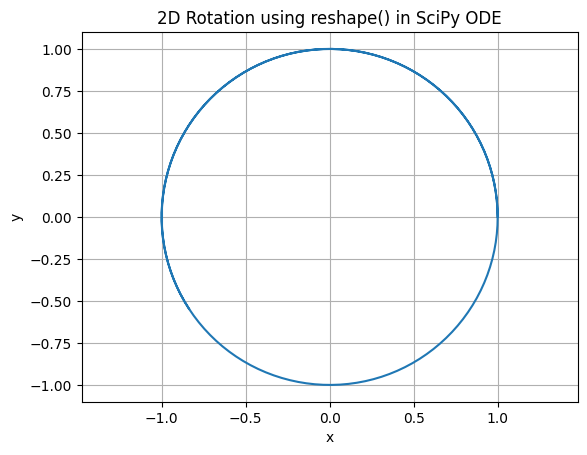

In [3]:
import numpy as np  # NumPy is used for mathematical operations like creating arrays and matrix math.
from scipy.integrate import solve_ivp  # solve_ivp solves differential equations over time.
import matplotlib.pyplot as plt  # For drawing graphs and visualization.

# Define the function for the differential system
def dX_dt(t, X):
    # A is a rotation matrix representing 90-degree counter-clockwise rotation
    A = np.array([[0, -1], [1, 0]])
    
    # Convert 1D state vector into a column (2x1) matrix
    X_matrix = X.reshape(2, 1)
    
    # Multiply A and X_matrix to get dX/dt
    dX = A @ X_matrix
    
    # Convert result back to 1D array for the solver
    return dX.flatten()

# Initial condition: starting at point (1, 0)
X0 = np.array([1, 0])

# Time span for simulation from t=0 to t=10
t_span = [0, 10]

# 200 evenly spaced time values between 0 and 10
t_eval = np.linspace(0, 10, 200)

# Solve the system
sol = solve_ivp(dX_dt, t_span, X0, t_eval=t_eval)

# Plot the result (x vs y)
plt.plot(sol.y[0], sol.y[1])
plt.title('2D Rotation using reshape() in SciPy ODE')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')  # Keep x and y axis equally scaled to show a proper circle
plt.grid()
plt.show()


## Example 7: Using NumPy linalg.norm inside SciPy.

- Norm Definition: np.linalg.norm() calculates the magnitude (length) of a vector, or the norm of a matrix, depending on the input i.e.
- For a Vector x = [x1, x2, x3, x4....., xn], the default norm is the Euclidean norm, computed as: ||x|| = sqrt(x1^2 + x2^2 + ......+ x^2n).

- SciPy deals heavily with numerical solutions, optimization, and ODEs, which often require calculating vector magnitudes or checking convergence.

- In Optimization(scipy.optimize), norms are often used in objective functions to minimize distance between predicted and actual outputs.

- We can pass a matrix to linalg.norm() and use various orders (ord) to compute matrix norms (e.g. Frobenius norm).

- Versatile Norm Orders: np.linalg.norm(x, ord=1) → Manhattan norm, ord=2 → Euclidean norm,ord=np.inf → max element, ord='fro' → Normal Matrices.

In [4]:
# This line imports the NumPy Library.
# NumPy helps us work with arrays, vectors, and do mathematical calculations efficiently.
import numpy as np
# This Imports the minimize function from SciPy's Optimization Module.
# minimize is used to find the Minimum value of a Function — it's often used for Solving Optimization Problems.
from scipy.optimize import minimize

# Objective Function that uses NumPy.
# The Function takes one input Argument, x, which is Expected to be a vector (like [x₀, x₁]).
# This function will be passed to the optimizer later, and it tells the Optimizer what value we want to Minimize.
def objective(x):
    # Minimize the distance from point (3, 4).
    # Inside the Function, we define a Target Point in 2D space: [3, 4].
    # This is the point that we want to move as close to as possible.
    # The np.array() function turns this list into a NumPy array, so we can do vector math.
    target = np.array([3, 4])
    # This performs Element-Wise Subtraction between x and the Target Vector.
    # If x = [0, 0], then x - target = [-3, -4].
    # This gives us the difference vector, which tells how far x is from the target in both x and y directions.
    # This line calculates the Euclidean norm (i.e., straight-line distance) between the point x and the target.np.linalg.norm() computes √((x₀ - 3)² + (x₁ - 4)²), which is the distance formula in 2D space.
    # In essence, this line tells: "How far is x from [3, 4]?"
    # The function returns the computed distance.
    # This returned value is what the optimization algorithm will try to minimize.
    # So, the optimizer will look for the input x that brings this distance as close to zero as possible.
    return np.linalg.norm(x - target)

# Initial Guess
# x0 is a Variable Name: We are creating a new variable called x0 and It stands for "initial guess for x" — the starting point for the optimization process.
# np.array([0.0, 0.0]): This part creates a NumPy Array containing Two Numbers: 0.0 and 0.0 and The result is a 2D vector: [0.0, 0.0], representing a point at the origin in a 2D space.
x0 = np.array([0.0, 0.0])

# Minimize the Norm i.e. Euclidean Distance.
# minimize(objective, x0): This line calls the Minimize Function from SciPy’s Optimize Module and The goal is to find the Minimum Value of the Function called objective, starting from the initial point x0.
# Objective is the Function being Minimized: Earlier in the code, objective was defined to return the Euclidean distance between a variable point x and a target point [3, 4].
result = minimize(objective, x0)
print("Minimum at:", result.x)

Minimum at: [3.         3.99999999]


## Example 8: Using NumPy Trace in SciPy system.

- np.trace() returns the sum of the diagonal elements of a square matrix. In math terms, if A is a matrix, trace(A) = A₁₁ + A₂₂ + ... + Aₙₙ.

- The Trace of a Matrix is Equal to the Sum of its Eigenvalues, which can give insight into Growth or Decay in a system over time.


In [13]:
def dX_dt(t, X):
    M = np.array([[t, 1], [-1, -t]])  # Time-dependent matrix
    feedback = np.trace(M)  # Sum of diagonal entries
    return feedback * X  # Scale X by this feedback

X0 = np.array([1, 1])
sol = solve_ivp(dX_dt, [0, 5], X0)
print(sol.y)


[[1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]]


## Example 9: Mixing NumPy sine with SciPy ODE.

- Sine Function Basics: np.sin(t) calculates the sine of t (in radians). It’s often used in Wave Motion, Oscillations, or Cyclic Processes.

- Time-Dependent Systems: By Adding np.sin(t) in the ODE Function, we make the System Evolve in a Time-Dependent, oscillatory way.

  

In [14]:
def dX_dt(t, X):
    # Rotational system modulated by sine wave
    return np.array([np.sin(t) * X[1], -np.sin(t) * X[0]])

X0 = np.array([1, 0])
sol = solve_ivp(dX_dt, [0, 10], X0)
print(sol.y)


[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  9.99999998e-01
   9.99980995e-01  9.43344242e-01  2.74163578e-01 -3.83399738e-01
  -1.83299131e-01  6.41804834e-01  9.97787164e-01  1.00095240e+00
   8.91997315e-01  1.34630620e-01 -4.10810728e-01 -2.66028648e-01]
 [ 0.00000000e+00 -5.00000000e-09 -6.04999939e-07 -6.16043674e-05
  -6.16522043e-03 -3.31845399e-01 -9.62525493e-01 -9.24692563e-01
  -9.84234440e-01 -7.69082524e-01 -9.26604652e-02 -4.79961889e-02
  -4.56700195e-01 -9.93795366e-01 -9.15021871e-01 -9.67096276e-01]]


## Example 10: Combining NumPy random and SciPy Solve.

- Random Number Generation: NumPy's np.random Module can Generate Arrays of Random Numbers—Uniform, Normal(Gaussian), Integers, etc.

- SciPy Solve: scipy.linalg.solve() is used to solve linear systems like Ax = b. Here, A and b can include Random Data to Simulate Variable Systems.

- Use Case – Random System of Equations: You can randomly generate matrix A and vector b, then solve Ax = b using scipy.linalg.solve.



In [5]:
import numpy as np
from scipy.linalg import solve

# Generate a random 3x3 matrix A and 3x1 vector b
np.random.seed(0)  # for reproducibility
A = np.random.rand(3, 3)
b = np.random.rand(3)

# Solve the linear system Ax = b
x = solve(A, b)

# Print results
print("Matrix A:\n", A)
print("Vector b:\n", b)
print("Solution x:\n", x)


Matrix A:
 [[0.5488135  0.71518937 0.60276338]
 [0.54488318 0.4236548  0.64589411]
 [0.43758721 0.891773   0.96366276]]
Vector b:
 [0.38344152 0.79172504 0.52889492]
Solution x:
 [ 0.89134069 -1.2236379   1.27644537]


## Features of SciPy's Relationship with NumPy.

## Feature 1: Shared Data Structure – NumPy Arrays.

- Understand how both SciPy and NumPy use the same Core Data Structure — the NumPy Array(ndarray) — to work Seamlessly Together.
  
- Shared Foundation: SciPy is built on top of NumPy, and both use the numpy.ndarray data type as the Basic Structure for Storing and Manipulating Numerical Data.

- Efficiency: Sharing the same Data Structure avoids Unnecessary Copying or Transformation, which helps in Performance and Memory Efficiency.

- SciPy Functions Expect NumPy Arrays: Functions like scipy.linalg.solve, scipy.optimize.minimize, and scipy.integrate.solve_ivp all expect inputs as NumPy arrays or formats that can be easily converted into them.

- Array Mutability: Arrays passed to SciPy Functions may be updated(in-place operations), so Understanding how Arrays are Stored and Accessed helps in optimizing usage.



In [16]:
import numpy as np
from scipy import linalg

a = np.array([[1, 2], [3, 4]])
print(type(a))  # Output: <class 'numpy.ndarray'>
print(linalg.inv(a))  # Uses NumPy array as input


<class 'numpy.ndarray'>
[[-2.   1. ]
 [ 1.5 -0.5]]


## Feature 2: SciPy Extends NumPy Functionalities.

- Built on Top of NumPy: SciPy is not a replacement for NumPy. Instead, it’s built on top of NumPy, meaning it uses NumPy's arrays and functions but adds more Powerful Tools.

- Advanced Mathematics & Algorithms : While NumPy provides basic mathematical operations (like sin, cos, matrix multiplication), SciPy adds advanced features like solving differential equations, signal processing, optimization, and statistics.

- Modular Design: SciPy has sub-packages such as:
1) scipy.linalg for linear algebra (more advanced than numpy.linalg).
2) scipy.optimize for Optimization Problems
3) scipy.integrate for Calculus and ODEs.
4) scipy.stats for Statistics.

  

In [17]:
import numpy as np
from scipy.linalg import det

a = np.array([[4, 2], [3, 1]])
print(det(a))  # Computes determinant


-2.0


## Feature 3: SciPy Uses NumPy’s Broadcasting and Slicing.

- Broadcasting:  In NumPy(and therefore in SciPy), broadcasting allows Operations between Arrays of Different Shapes — NumPy Automatically Stretches the Smaller one to match the Shape of the Larger one without Copying Data.

- SciPy Inherits This: Since SciPy is built on NumPy, it fully supports Broadcasting Rules when Handling Arrays, especially in Functions like scipy.optimize, scipy.signal, or scipy.integrate.

- Broadcasting removes the need for Explicit Loops, which makes your code Shorter, Faster, and more Efficient. This is Extremely Useful in Mathematical Modeling.

- Slicing Arrays: Like Python lists, NumPy arrays (and arrays passed into SciPy functions) can be sliced: for example, arr[2:5] accesses parts of the array. SciPy functions often use slices when analyzing or transforming only a section of data.
Like Python lists, NumPy arrays (and arrays passed into SciPy functions) can be sliced: for example, arr[2:5] accesses parts of the array. SciPy functions often use slices when analyzing or transforming only a section of data.

- Broadcasting in Equations: For example, in a system of ODEs, if you want to apply a damping term to all elements of a vector, you can write -0.1 * y, and SciPy will apply that term to every element — no loop needed.

- Matrix Operations: In many SciPy linear algebra or signal functions, broadcasting allows you to add vectors to matrices, or apply filters across multiple signals at once.

- Efficient Memory Use: Broadcasting doesn't copy data, it views it in a different shape. SciPy relies on this to handle large arrays efficiently without wasting memory.

- Compatibility Across Modules: Whether you're doing signal processing (scipy.signal.convolve) or interpolation (scipy.interpolate), broadcasting allows these functions to accept arrays of various dimensions naturally.

- Custom Equations in ODEs: In solve_ivp, you can define a vector function like dy/dt = -0.5 * y + np.sin(t), and y will be a vector. Thanks to broadcasting, SciPy applies the equation to every element of y.

- Slicing with Masks or Conditions: You can pass in logical conditions to SciPy functions using NumPy slicing — for example, filtering only values y[y > 0] in an array before plotting or analyzing.

- High-Level Function Writing: Broadcasting lets you write equations in math-like syntax, which SciPy can directly solve or optimize. This means fewer bugs and cleaner scientific code.

- Vectorization + SciPy = Performance: With NumPy's broadcasting and slicing + SciPy’s solvers, you get the benefit of vectorized computation, often much faster than for-loops.


In [18]:
import numpy as np
from scipy.special import expit  # Logistic function

x = np.array([-5, 0, 5])
print(expit(x))  # Broadcasts over the array


[0.00669285 0.5        0.99330715]


## Feature 4: SciPy Leverages NumPy’s Speed.

- Built on C and Fortran: NumPy itself is implemented in low-level languages like C and Fortran, which are extremely fast. SciPy uses NumPy's array and computation infrastructure to inherit that speed.

- Vectorized Operations: NumPy allows you to apply mathematical operations on entire arrays without writing Python loops. SciPy takes advantage of this vectorization to process large datasets very efficiently.

- No Explicit Loops: When you write a * b in NumPy, it doesn't loop element by element in Python; it computes the operation at compiled speed. SciPy uses this wherever possible, especially in linear algebra and differential equations.

- Efficient Memory Layout: NumPy arrays use contiguous memory and are much faster for SciPy to read and write compared to native Python lists. This reduces latency and improves numerical performance.

- Faster Math Computations: Whether you're using scipy.linalg, scipy.optimize, or scipy.fft, the math under the hood runs on optimized compiled code, making SciPy many times faster than writing raw Python math.

- Sparse Matrix Computation: SciPy has a Sparse Module that uses NumPy’s Efficiency to Store and Compute with Large, Mostly-empty matrices — common in Scientific modeling or engineering and A Sparse matrix in which most of its elements are zero. It is characterized by a small number of non-zero elements compared to the total number of elements (mxn). In other words, a sparse matrix has a significant proportion of zero values, often exceeding half of the total elements i.e. given m and n, a Sparse Matrix of size mxn can be defined as follows: m: The Number of Rows and n: The Number of Columns.

- Multidimensional Array Support: NumPy Arrays support High-Dimensional Data(2D, 3D, and more), which SciPy uses for Simulations, Image Processing, and Numerical Solvers without Needing to Reshape Data Constantly.

- Data Alignment: NumPy handles the indexing and alignment of data efficiently. SciPy uses this internally for signal filtering, root-finding, and interpolation, minimizing overhead.

- Shared C-Level APIs: SciPy functions often call NumPy C-level functions directly, giving near-native speed without manually coding in C.

- NumPy as the Backend: SciPy doesn’t re-implement math — it calls NumPy internally, especially for basic tasks like summing arrays, matrix Multiplication, and broadcasting.

- Parallel Capabilities: Some NumPy operations can be parallelized (via libraries like OpenBLAS or MKL). SciPy benefits from this parallel execution when NumPy handles large matrix tasks or FFTs.

- Consistent Performance Across Modules: Whether it's signal processing, integration, optimization, or interpolation — SciPy's performance is tightly bound to how fast NumPy handles core math, ensuring reliable and consistent speed.

In [19]:
import numpy as np
from scipy import fft

x = np.random.rand(1000)
y = fft.fft(x)
print(y[:5])


[489.65833277-0.j          -9.65177784-7.54753387j
  -2.81410062+3.35094817j -13.3521424 -7.62922185j
  20.62618564-0.14311849j]


## Feature 5: Interchangeable Arrays between SciPy and NumPy.

- Shared Data Type: Both NumPy and SciPy use the same array data type: numpy.ndarray. This means any array created in NumPy can be directly used in SciPy functions without any conversion.

- No Need to Re-Define Data: If you define a NumPy array (e.g., a = np.array([1, 2, 3])), you can pass it to a SciPy function like scipy.integrate.simps(a) or scipy.fft(a) immediately.

- Bi-Directional Compatibility: Output from SciPy (like results from solvers, transforms, or filters) are also NumPy arrays. You can further analyze, reshape, or plot them using NumPy functions without any special steps.

- No Copying Needed: NumPy and SciPy use references to the same data memory space. So using one in the other doesn’t create unnecessary copies, which saves memory and improves speed.

- Cleaner Code: Because Arrays don’t need to be Restructured or Converted, your Code remains Short, Clean, and Easier to Read and Debug.

- Universal Syntax: All indexing, slicing, and reshaping techniques in NumPy are valid for arrays used inside SciPy. You can use arr[::2], arr.T, etc., the same way.

- NumPy Arrays as First-Class Input: Every SciPy module (e.g., scipy.optimize, scipy.signal, scipy.sparse) is built to accept NumPy arrays. They are the default format for numerical input and output.

- Works in All Domains: Whether you're working in integration, signal processing, image filtering, or solving differential equations, NumPy arrays are the consistent data structure shared across SciPy.

- Chaining NumPy and SciPy: You can use a NumPy function to prepare data (like np.linspace, np.random, np.reshape) and pass it immediately into SciPy functions, making workflow seamless.

- Mathematical Operations Chain: NumPy lets you do basic math; SciPy adds Scientific tools. Since both work on the Same arrays, you can mix them in the Same Expression: e.g., np.exp(scipy.integrate.cumtrapz(...)).

- Interoperability with Other Libraries: Libraries like Matplotlib, Pandas, or Scikit-Learn also use NumPy Arrays. Because SciPy shares this format, it fits Smoothly into Entire Scientific Pipelines.

- Data Consistency: Using one Array format ensures your Variables stay Consistent across Different Computations and Plots, reducing bugs and confusion.

In [6]:
from scipy.integrate import simpson
import numpy as np
from scipy.integrate import simpson

x = np.linspace(0, 10, 100)
y = np.sin(x)

result = simpson(y, x)
print("Result of integration using Simpson's rule:", result)



Result of integration using Simpson's rule: 1.8390764529333192


## Feature 6: Shared Mathematical Functions.

- NumPy Covers Core Math: NumPy provides the Fundamental building blocks for Numerical operations, like arrays, matrix multiplication, element-wise functions (sin, exp, etc.), and basic Linear Algebra.

- SciPy Adds Specialized Functions: SciPy is built on top of NumPy and expands its functionality with Advanced Tools: Optimization, Integration, interpolation, differential equations, signal processing, and more.

- SciPy = Scientific Toolkit: Where NumPy stops at general-purpose mathematics, SciPy starts with domain-specific tasks such as solving ODEs, fitting curves, or minimizing functions.

- Modular Design: SciPy is divided into Modules (scipy.optimize, scipy.signal, scipy.integrate, scipy.sparse, etc.), each extending a topic beyond NumPy’s basic capabilities.

- NumPy Arrays as Input: All Advanced SciPy Functions work Directly on NumPy Arrays. This keeps Data Flow Simple and Eliminates the need for conversions.

- Same Syntax Style: SciPy maintains a NumPy-like syntax (e.g., passing arrays, shapes, and slicing), which makes it easy for NumPy users to transition to SciPy.

- Example – Optimization: NumPy lets you define and evaluate functions. SciPy goes further: it can minimize functions or solve systems of Equations using Numerical methods.

- Example – Signal Processing: NumPy can create signals and analyze them. SciPy adds filters (like Butterworth), transforms, and convolution tools for Engineering Applications.

- Example – Integration: NumPy helps build function data points. SciPy can numerically integrate those functions, both as definite integrals and solutions to differential equations.

- SciPy as a Power Tool: Think of NumPy as your Basic Calculator and SciPy as your Scientific Lab. SciPy reuses NumPy's Engine but adds serious scientific computation.

- Consistent Documentation: The Functions and Docstrings in SciPy often refer to NumPy objects. This Creates consistency in understanding and usage.

- Powerful Together: While SciPy doesn’t replace NumPy, it extends it. For most real-world scientific tasks, you'll use both together — NumPy for Structure, SciPy for Advanced Tools.



In [21]:
import numpy as np
from scipy.special import gamma

print(gamma(5))  # Output: 24 (Gamma function of 5 = 4!)


24.0


## Feature 7: Optimization Functions on NumPy Arrays.

- This Feature highlights the Interoperability between SciPy Optimization tools and NumPy Arrays. Optimization problems—like Minimizing Cost, Energy, or Distance—are common in Science and Engineering. SciPy's Optimization Functions such as minimize, least_squares, and others accept NumPy Arrays as Input and Output.

- SciPy Optimization Functions: Tools like scipy.optimize.minimize() solve minimization problems — that is, they try to find the input values that make a function as small as possible.

- NumPy Arrays as Inputs: These functions Expect the Input Variables(Decision Variables) to be passed as NumPy Arrays, because NumPy makes Vector Math Fast and Easy.

- NumPy Inside Objective Functions: When writing the objective (or cost) function, we often use NumPy operations (like np.linalg.norm, np.sum, etc.) for efficient computation.

- Initial Guess as NumPy Array: Optimization needs a starting point to begin iteration. This guess is typically given as a NumPy Array, e.g., x0 = np.array([1.0, 2.0]).

- Gradient Descent Logic: Under the hood, Optimizers often rely on Gradients(derivatives), which require Smooth Numerical functions — NumPy’s Functions provide this.

- Output Format: The result from optimization is typically an object that includes .x (best solution) and .fun (function value at that point), both often in NumPy format.

- Supports Multi-Dimensional Arrays: NumPy allows easy scaling to higher dimensions — making it suitable for solving complex optimization tasks in many variables.

- No Need for Loops: Thanks to broadcasting and vectorization, optimization with NumPy often avoids loops, making it cleaner and faster.

- Use in Machine Learning: Many machine learning problems boil down to optimization (e.g., minimizing a loss function). NumPy + SciPy is a foundation for this.

- Real-World Applications: Used in curve fitting, engineering design, economic modeling, etc., where parameters must be "tuned" for best results.

- Smooth Interface: NumPy’s syntax aligns perfectly with how optimization functions expect inputs and process outputs.

- Convenience and Readability: Using NumPy makes optimization code more Concise, Expressive, and Easy to Debug.





## Optimization Functions in SciPy.

- Optimization is the process of finding the Best Solution(Maximum or Minimum) from all Possible Solutions, usually under some Constraints.

- Purpose: Optimization Functions help us find the Minimum or Maximum of a Function, often under Constraints.

- Used In: Fields like engineering, economics, machine learning, physics, etc.

- SciPy Library: SciPy offers powerful tools under scipy.optimize for various types of optimization tasks.

- Types:

1) Unconstrained Optimization (no constraints on inputs)

2) Constrained Optimization (some conditions must be met)

- Common Functions:

1) minimize(): General-purpose minimizer

2) least_squares(): Solve least-squares problems

3) curve_fit(): Fit data to a function

4) linprog(): Linear programming

- Objective Function: The function you want to minimize (or maximize).

- Initial Guess: Most algorithms need a starting point for their search.

- Constraints and Bounds: Some functions allow you to limit variable ranges or enforce conditions.

- Methods: Algorithms used internally, such as BFGS, CG, Nelder-Mead, trust-constr, and highs.

- Returns: A result object containing the optimal values, function value, success status, etc.

- Use NumPy: Most optimization functions work with NumPy arrays for input and output.

- Visualization: You can often plot objective functions to understand behavior before and after optimization.



## Examples of the Optimization Functions

## scipy.optimize.minimize()

- This is the core function for minimizing scalar-valued functions (functions that return a single number).

- It finds the value of variables x that minimizes an objective (cost) function f(x).

- It can include constraints and bounds.

- scipy.optimize.minimize(fun, x0, args=(), method=None, bounds=None, constraints=(), tol=None, options={})

- fun: The function you want to minimize. It should take a NumPy array and return a scalar (single number).

- x0: Initial guess — a NumPy array with starting values of variables.

- args: Extra arguments to pass to the objective function (optional).

- method: Specifies the algorithm. Common choices: 'BFGS', 'CG', 'L-BFGS-B', 'SLSQP'.

- bounds: A list of (min, max) pairs for each element in x.

- constraints: Optional dictionary describing constraints. Can be equality or inequality.

- tol: Tolerance for stopping criteria.

- options: Dictionary of solver options, like 'maxiter', 'disp' for display.

- Returns a result object, where result.x gives the Optimal Solution.


## Example : Minimize a Quadratic Function.

- The Goal of this Program is to find the Minimum of a Mathematical Function using SciPy’s Optimization Tools. In this case, the function is: f(x, y) = x^2 + y^2. The goal is to find values of x and y that Minimize this Function.

- Optimization is the process of finding the Best Solution to a Problem — in this case, the Smallest Value of a Function. Here, we want to find the point (x, y) where the output of the function x^2 + y^2 is as small as Possible.

- This is an example of Unconstrained Optimization — meaning:
1) There are no limits or restrictions on x and y.
2) The Optimizer is free to move in any Direction to find the Minimum.

- The Shape of the Function: The function x^2 + y^2 forms a Paraboloid — a 3D bowl-shaped surface.

- The objective() Function: Represents the Target Function to Minimize and Takes an array x (with two elements: x[0] and x[1]) and returns the computed value i.e. x^2 + y^2.

- Initial Guess i.e. x0 = [1, 1] is the starting point for the algorithm as Optimization methods need a starting guess to begin the search for a better solution and From (1, 1), the algorithm will try to reduce the value of the function step by step.

- The minimize() Function: This function automatically applies an optimization algorithm (default is 'BFGS') to minimize the objective function and it uses the Starting Point x0 and Iteratively adjusts the Values to Lower the Function result.

-  Gradient-Based Search: By default, minimize uses gradient-based optimization, which means that It calculates the slope of the function at the current point and Then it moves in the direction where the function decreases fastest.

- Solution Output: The .x in the result object gives the values of x and y at the point where the function is minimum and For this function, the result should be very close to [0. 0.], the lowest point of the bowl.








  

In [2]:
import numpy as np
from scipy.optimize import minimize

def objective(x):
    return x[0]**2 + x[1]**2  # A simple paraboloid

x0 = [1, 1]  # Initial guess
result = minimize(objective, x0)
print("Minimum at:", result.x)


Minimum at: [-1.07505143e-08 -1.07505143e-08]


## scipy.optimize.least_squares()

- Solves Non - Linear Least-Squares Problems.

- Non- linear Least-Squares Problems are mathematical methods used to fit a curve to data when the curve’s shape (the model) is nonlinear — meaning it doesn’t form a straight line or flat surface.

- The term "least squares" comes from trying to make the sum of squared differences (errors) between observed data points and predicted values as small as possible i.e. minimize sigma(y(observed) - y(model))^2.

- Used for Curve Fitting: You use it when you want to fit a curve (model) to data, but the curve has a Non - Linear Shape — such as Exponential, sine, Logarithmic, etc.

- It’s nonlinear when the function or model you’re trying to fit depends nonlinearly on its parameters. Example: y = a.e^bx. This is nonlinear because a and b are inside a nonlinear function (exponential).

- Goal: Find Best Parameters: We try to find the values of Parameters(like a, b, c, etc.) that make the Model Fit the Observed Data as closely as Possible.
  
- Minimizes the Sum of Squared Residuals, i.e., Differences between Predicted and Actual Values.

- scipy.optimize.least_squares(fun, x0, args=(), bounds=(-np.inf, np.inf), method='trf')

- fun: A function that returns an array of residuals (not a scalar).

- x0: Initial guess for parameters.

- It minimizes the sum of fun(x)**2 — ideal for fitting.

- Supports bounds to restrict the parameter values.

- Uses methods like 'trf', 'dogbox', or 'lm'.

- Returns a result object with .x (solution), .cost (sum of squares), .fun (residuals).

## Example: Basic Least Squares Problem.

- The Least Squares Method helps us find the Best-Fitting line or Curve through a set of Points by Minimizing the Errors(differences between Predicted and Actual Values).

- Least Squares mean that It  minimize the Sum of the Squares of the Errors. Squaring the Errors ensures they are all Positive and Penalizes Large Errors more than Small Ones.

- In this, we are trying to solve an equation like this: A·x ≈ b, A is a known matrix (inputs or features), x is a vector of unknowns (what you want to find), b is a known vector (observed outputs or measurements).

- We write "approximately equal to" (≈) because in many real-world problems, no exact solution exists (due to noise, errors, or overdetermined systems), so we find the "closest" possible solution.

- Error Vector (Residuals): Let the residual vector be: r = A·x - b , This vector r represents the difference between our prediction (A·x) and actual data (b).

- Least Squares Objective Function: We measure the size of the error vector using the square of its length (Euclidean norm squared): minimize ||A·x - b||².

- Normal Equation (Linear Least Squares): If A is an m × n matrix and m > n (more equations than unknowns), we solve the normal equation:AᵀA·x = Aᵀb,
Here, Aᵀ is the transpose of A.

- Solving for x, If AᵀA is invertible, we can directly solve for x: x = (AᵀA)⁻¹·Aᵀ·b and this gives us the least-squares solution to the system.











In [ ]:
from scipy.optimize import least_squares
import numpy as np

def fun(x):
    return x**2 - 4  # Residual function: (x^2 - 4)

x0 = [1.0]  # Initial guess
result = least_squares(fun, x0)
print("Solution:", result.x)


## scipy.optimize.curve_fit()

- A Simplified Interface for Non - Linear Curve Fitting.

- linprog() is used to solve linear programming problems of the form: Minimize: cᵀx, subject to A_ub x ≤ b_ub, A_eq x = b_eq, and bounds on Variables.

- Objective Function i.e. cᵀx You want to minimize a function like 2x + 3y. Here:
1) c is the cost or coefficient vector [2, 3].
2) x is the variable vector [x, y].
3) cᵀx just means: 2x + 3y (a Linear function).



- curve_fit() is a function from SciPy used to fit a Non - Linear Function to a set of Data Points. You provide it with:
1) A model (a Python Function).
2) Some x Data and y Data.
3) It Estimates the Best Parameters for the Model to match the Data.

-  Purpose of curve_fit(): The goal is to adjust the Model parameters so that the Predicted Values are as close as possible to the Observed Data — i.e. Minimize the Errors.

-  least_squares() is a more General Optimization Function used to solve Non - Linear Least - Squares Problems, where we want to Minimize the sum of Squares of Residuals(Differences between Observed and Predicted Values).

-  scipy.optimize.curve_fit() Internally uses least_squares i.e. Internally, curve_fit() calls least_squares() to do the heavy mathematical work of minimizing the error between your model and the Actual Data.

- curve_fit() Automatically builds the Residual Function — the function that returns the difference between the model output and the real data. This is exactly the input that least_squares() expects.


- Fits a user-defined function to data by Minimizing Squared Errors.

- scipy.optimize.curve_fit(f, xdata, ydata, p0=None, bounds=(-np.inf, np.inf))

- f: The function to fit — must take x and parameter vector p, return y.

- xdata: Input x-values (independent variable).

- ydata: Actual y-values (dependent variable).

- p0: Initial guess for the parameters.



## Example: Minimize cost: c = [2, 3], subject to Constraints.

- The goal is to minimize 2x + 3y, which could represent cost.

- There are Two Constraints:
1) x + y ≤ 10 (limited total resources).
2) x + 3y ≤ 15 (another limit).

- We define that x and y must be non-negative.

- The linprog() function solves this and returns the optimal x and y.

In [4]:
# This Imports the linprog() Function from SciPy's Optimize Module, which is used to solve Linear Programming Problems.
from scipy.optimize import linprog

# Objective function: Minimize 2x + 3y i.e.  This means you're trying to Minimize the Function i.e. Objective: 2x + 3y.
# x and y are the decision variables (unknowns).
# The Coefficients 2 and 3 represent the Cost per unit of x and y.

c = [2, 3]

# Inequality constraints: 
# 1x + 1y ≤ 10
# 1x + 3y ≤ 15
# A is a matrix where each row represents Coefficients of a Constraint.
# b is a vector of Upper Bounds.
# Format: A_ub x ≤ b_ub → linprog expects this matrix form.
A = [[1, 1], [1, 3]]
b = [10, 15]

# Bounds: 0 ≤ x ≤ None, 0 ≤ y ≤ None.
# These specify that: 𝑥 ≥ 0 and 𝑦 ≥ 0
x_bounds = (0, None)
y_bounds = (0, None)

# This line runs the optimizer: It minimizes the cost function 2x + 3y.
# It returns a Result Object containing: result.fun → The Minimized Cost i.e. The Lowest Possible Value of your Objective Function that still satisfies all the constraints.
# result.x → the best values of x and y (the optimal solution) i.e. The exact Amounts of the Variables that result in that Minimum Cost.


result = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds])
print("Optimal value:", result.fun)
print("Optimal solution (x, y):", result.x)


Optimal value: 0.0
Optimal solution (x, y): [0. 0.]


## scipy.optimize.fmin()

- Uses the Nelder-Mead Simplex Algorithm for Minimization.

- The Nelder-Mead Algorithm is a Popular Method for finding the Minimum of a Function, especially when Derivatives are not available or are Expensive to compute.

- It finds the Minimum Value of a Function (usually one with several variables) without using Gradients or Derivatives.

- Derivative-Free Optimization: Nelder-Mead does not require the gradient or any derivative information.

- Simplex-Based Approach: Operates using a geometric shape called a simplex and A simplex is made of n + 1 points in  n-dimensional space (e.g., a triangle in 2D).

- Objective Function: The goal is to minimize a scalar-valued function f(x), where x belongs to (Real Numbers)^n. Example: f(x, y) = x^2 + y^2.

- Function Evaluations: At each iteration, the function f is evaluated at the vertices of the simplex.

- The points are sorted based on their Function Values. The points are sorted based on their function values: f(x1)<=f(x2)<=.....f(xn + 1). x1 is best, xn+1 is the worst.

- Nature of the Algorithm: It is a Heuristic Algorithm, it may not converge for some functions or in high dimensions and Works well for smooth, unconstrained, low-dimensional problems.


- The algorithm starts with an initial simplex built around a user-provided starting point.

1) Simple but limited; doesn't support Bounds or Constraints.

2) scipy.optimize.fmin(func, x0)

3) func: The objective function to minimize.

4) x0: Initial guess.

## Example:  Objective Function of  Nelder-Mead Simplex Algorithm.

- This example minimizes the function f(x) = x^2 + y^2 + 3, a simple convex paraboloid, using the Nelder-Mead method.



In [2]:
from scipy.optimize import minimize  # Provides access to various optimization algorithms, including Nelder-Mead.
import numpy as np  # Used for Handling Arrays, though in this case, it supports Mathematical Operations inside the Function.


# Define the Objective Function f(x).
# This function takes a Vector x (which has two components: x[0] and x[1]) and returns: f(x, y) = x^2 + y^2 + 3. 
# This is a Paraboloid — a Simple Bowl-Shaped Surface with its Minimum at the origin (0,0), where the Function equals 3.
# Optimization Goal i.e. The goal is to find the values of x and y that minimize the function f(x). The optimizer does not require gradients because we use Nelder-Mead, which is derivative-free.
def f(x):
    return x[0]**2 + x[1]**2 + 3
    
# Initial Guess [2, 1] i.e. The Algorithm starts searching from the point (2, 1) in 2D space.
# This helps initialize the simplex, a triangle in 2D Optimization.

res = minimize(f, [2, 1], method='Nelder-Mead')

# print(res.x) Prints the (x, y) Coordinates of the Minimum Point found.
# Since the True Minimum of f(x, y) = x^2 + y^2 + 3 s at (0,0), the result should be very close to (0, 0).
print(res.x) 


[-3.03662006e-05 -3.62769110e-05]


## Example: Minimizing a Quadratic Function Using scipy.optimize.minimize with Nelder-Mead Method.

- A quadratic function is given that has a minimum value somewhere in 2D space.

- We want to find the lowest point (minimum value) of this function.

- Instead of checking every value manually, we use an optimization algorithm.

- We define the function as a Python function.

- We provide a starting guess—this tells the optimizer where to begin.

- We choose the Nelder-Mead method which uses geometric transformations of shapes.

- The minimize() function tries different values of x and y to reduce the output value.

- It keeps changing the inputs until the function value can't go lower.

- The output includes the lowest value of the function it could find.

- It also tells the (x, y) values where this minimum happens.

- This is a practical method to solve math problems without needing calculus or plotting.

- It can be used for parameter tuning, physics modeling, or other scientific uses.

In [7]:
# NumPy is used for Numerical Operations.

import numpy as np

# minimize is used to find the Minimum value of a Function.

from scipy.optimize import minimize

# Step 1: Define the Quadratic Function to Minimize.
# This is a Quadratic Function of two Variables: f(x, y) = x^2 + y^2 + 2xy + 3x + 4y + 5.



def quadratic_function(x):
    return x[0]**2 + x[1]**2 + 2*x[0]*x[1] + 3*x[0] + 4*x[1] + 5

# Step 2: Provide an Initial Guess for x as input: [x0, x1].

initial_guess = [0, 0]

# Step 3: Use minimize() with Nelder-Mead Method.
# quadratic_function is the Objective to Minimize.
# initial_guess is the starting point.
# Nelder-Mead is a method that doesn’t require Derivatives.

result = minimize(quadratic_function, initial_guess, method='Nelder-Mead')

# Step 4: Print the Results.
# result.fun contains the Minimum Function Value Found.
# result.x contains the coordinates (x, y) of the Minimum.


print("Minimum value:", result.fun)
print("At point:", result.x)


Minimum value: -5140436800240723.0
At point: [ 2.88863699e+15 -2.88863699e+15]


## scipy.optimize.linprog()

- Solves Linear Optimization Problems, like Maximizing Profit or Minimizing Cost, under Linear constraints.

- Objective Function and Constraints are all Linear.

- scipy.optimize.linprog(c, A_ub=None, b_ub=None, A_eq=None, b_eq=None, bounds=None)

- c: Coefficients of the linear objective function.

- A_ub, b_ub: Inequality constraints (Ax ≤ b).

- A_eq, b_eq: Equality constraints (Ax = b).

- bounds: Limits on variables (x >= 0 by default).

## Example 1: Basic Minimization Problem.

- A Basic Minimization Problem is a type of Mathematical Problem where we try to find the Smallest Possible Value of a Certain Function(called the Objective Function) while following some Rules or Constraints.

- Minimization means finding the Lowest Value of a Function(like Cost, Distance, or Energy).

- For example, you might want to find the Cheapest Way to do something or the Shortest Distance to Travel.

-  Objective Function: This is the Function you want to Minimize. Example: f(x) = x² — you want to find the value of x that gives the smallest f(x).

-  Variables: These are the unknown values(like x, y, etc.) you are solving for. You adjust these variables to make the function as small as possible.

-  Constraints (Optional): Sometimes, you have rules or limits for the values of your Variables. Example: x ≥ 0, or x + y ≤ 10.

-  Global vs. Local Minimum: A Global Minimum is the Smallest Value of the Function across the Whole Domain.
- A local minimum is the smallest value only in a small neighborhood around a point.

  







In [5]:
# This line Imports the linprog() Function from SciPy’s Optimize Module.
# linprog() is used to solve linear programming problems, typically Minimization Problems with Linear Constraints.
from scipy.optimize import linprog

# Minimize: 2x + 3y.
# We are trying to minimize the cost function 2x + 3y.
# c is a list of Coefficients from the Objective Function. The order matters: it corresponds to the Variables x and y.
c = [2, 3]

# Constraints: x + y <= 10, x + 3y <= 15.
# This Matrix represents the Left-Hand sides of the Inequality Constraints.
# First row: 1*x + 1*y (i.e., x + y).
# Second row: 1*x + 3*y (i.e., x + 3y).
# This Matrix must match the shape of the number of Constraints × Number of Variables.
A = [[1, 1], [1, 3]]

# This is the Right - Hand side of the Inequalities.
# It corresponds to the Maximum Values allowed for each Constraint.
# So the constraints are: x + y ≤ 10  and x + 3y ≤ 15.
b = [10, 15]

# Bounds: x >= 0, y >= 0.
# These lines specify that both x and y must be non-negative.
# (0, None) means each variable can go from 0 up to infinity.
# This reflects a real-world restriction where variables (like quantity, money) can’t be negative.
x_bounds = (0, None)
y_bounds = (0, None)

# This is where the optimization happens.
# c: Objective function coefficients
# A_ub and b_ub: Define the inequality constraints Ax ≤ b
# bounds: Specify valid ranges for x and y
# The Function returns an object called result that stores the solution details.
result = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds])

# .fun gives the minimum value of the objective function 2x + 3y under the given constraints.
# This is the final Minimized Cost.
print("Optimal value:", result.fun)

# .x returns the values of variables x and y that give the optimal (minimum) result.
# This shows which combination of x and y produces the lowest value of 2x + 3y.
print("Optimal solution:", result.x)

Optimal value: 0.0
Optimal solution: [0. 0.]


## Feature 8: SciPy Depends on NumPy Internally.

- SciPy Is Built on Top of NumPy: SciPy is an extension of NumPy. It uses NumPy’s array and mathematical capabilities as a foundation.

- NumPy Handles Arrays and Basic Math: NumPy provides tools to work with arrays, matrix operations, and basic numerical functions like sin, cos, log, etc.

- SciPy Adds Advanced Mathematical Tools: SciPy builds on NumPy to offer specialized functionality like integration, optimization, interpolation, and linear algebra.

- Shared Data Structures: Both SciPy and NumPy use the same ndarray object to store and process data, which ensures smooth compatibility.

- No SciPy Without NumPy: SciPy functions cannot run without NumPy. When you install SciPy, NumPy is installed automatically.

- SciPy Functions Expect NumPy Arrays: Functions in SciPy like scipy.optimize.minimize() or scipy.integrate.quad() often expect inputs in the form of NumPy arrays.

- SciPy Uses NumPy for Internal Calculations: Even when you call a SciPy function, it may internally call a NumPy function to handle array operations or mathematical calculations.

- Efficient and Fast: Since NumPy is highly optimized (often using C behind the scenes), SciPy gains speed and performance by using it.

- Consistency Across Libraries: Because both libraries share structures and syntax, your code remains consistent and easier to maintain.

- Combined Power: NumPy gives you power over raw numerical arrays, while SciPy gives you powerful scientific algorithms built on top of those arrays.

- SciPy Imports NumPy Internally: You can check that SciPy modules do import numpy as np inside their code base.

- Real-World Usage: For example, solving a system of equations in SciPy uses NumPy's dot() or linalg.inv() functions internally.

## Example: Solving a Linear System.

- Goal: This program solves a system of two linear equations written in the form A.x = b, where:
1) A is a matrix containing the coefficients of the equations.
2) x is the unknown vector (the solution).
3) b is the result/output vector.

- Matrix A (Coefficients): The matrix A = [[3, 2], [1, 2]] represents the coefficients of two equations:
3x + 2y = ?
1x + 2y = ?

- Vector b (Results): The vector b = [2, 4] contains the Right - Hand sides of the Equations:
3x + 2y = 2
1x + 2y = 4

- Unknowns x and y: The goal is to find the values of x and y that satisfy both equations simultaneously.

- NumPy Arrays: Both A and b are created using np.array() to ensure they are treated as numerical arrays that support matrix operations.

- Using SciPy’s solve() Function: The solve() function from scipy.linalg is a high-level method used for solving systems of linear equations.

  

In [6]:
# 1. Import the NumPy library for handling arrays and matrices.
import numpy as np

# 2. Import the solve function from SciPy's linear algebra module.
#    This function helps solve systems of linear equations of the form A·x = b.
from scipy.linalg import solve

# 3. Define the coefficient matrix A.
#    Each row represents the coefficients of a linear equation.
#    For example, 3x + 2y = 2 and 1x + 2y = 4
A = np.array([[3, 2],  # First equation: 3x + 2y
              [1, 2]]) # Second equation: 1x + 2y

# 4. Define the constant vector b.
#    These are the values on the right side of the equations.
b = np.array([2, 4])  # Corresponding to: 3x + 2y = 2 and 1x + 2y = 4

# 5. Use the solve() function to solve the system A.x = b.
#    It finds the values of x and y that satisfy both equations.
x = solve(A, b)

# 6. The solution 'x' contains the values for the variables.
#    In this case, x[0] is the value of 'x' and x[1] is the value of 'y'.

# 7. Print the solution to the console.
#    This tells us the values of x and y that solve the original system.
print("Solution:", x)

# 8. This method avoids manually inverting the matrix, which is less efficient and can cause errors.

# 9. This approach is scalable — it works the same way for larger systems of equations (3 or more variables).

Solution: [-1.   2.5]


## Feature 9: Shared Data Manipulation Tools.

- NumPy and SciPy Share the Same Data Type: Both libraries work with the ndarray (NumPy array), so you can easily pass data back and forth between them.

- No Need to Convert Between Formats: If you load or create data using NumPy, you can directly feed it into SciPy functions without converting it.

- Common Tools Like Reshape, Slice, Transpose: You can use tools like reshape(), transpose(), and slicing (e.g., x[1:5]) in both libraries without compatibility issues.

- Vectorized Operations Work Seamlessly: You can perform math operations (+, *, np.exp(), etc.) on arrays, and those same arrays can be used in SciPy functions.

- SciPy Doesn’t Duplicate NumPy Tools: SciPy doesn’t rewrite functions like mean(), reshape(), or dot() — it uses NumPy's implementations internally.

- Efficient Data Handling: This shared approach means data is processed quickly and efficiently without unnecessary copying.

- Integrated Functionality for Math, Stats, and More: You can prepare or clean data using NumPy tools and then run simulations, models, or analysis with SciPy.

- Shared Data Flow in Pipelines: In data science workflows, you often preprocess with NumPy and then analyze or optimize with SciPy.

- Consistent Indexing and Broadcasting Rules: Whether in NumPy or SciPy, the way arrays behave (indexing, shapes, broadcasting) is the same.

- One Format for All Kinds of Scientific Work: This avoids confusion and allows building scientific or engineering systems with minimal redundancy.

- Memory Efficiency: Because both use the same object type, operations don’t create unnecessary temporary copies of data.

## Example : NumPy Array Manipulation + SciPy Optimization.

- Purpose of the Program: The program aims to find the minimum value of a simple mathematical function f(x, y) = x^2 + y^2, which is a paraboloid — a bowl-shaped surface with its lowest point (minimum) at the origin.

- NumPy Array Creation: The initial guess for the optimizer is created as a NumPy array x0 = np.array([2.0, 3.0]). This means we are starting the search for the minimum at the point (2, 3) on the surface.

- Array Reshaping with NumPy: The line x0 = x0.reshape(2) ensures that the initial guess is a 1D array with two elements. This step is a basic array manipulation, though it doesn’t change anything in this case, because the array already has the right shape.

- Function Definition: The function f(x) calculates x^2 + y^2, where x[0] is x and x[1] is y. This function returns the “height” of the point (x, y) on the surface.

- Optimization Goal: The goal is to Minimize this function, meaning we want to find the lowest point on the paraboloid — which will be at or near (0, 0) because that gives the smallest value of x^2 + y^2 = 0.

- SciPy Optimization: scipy.optimize.minimize() is used to perform the optimization. It takes in the function f and the starting point x0 and tries to move toward the minimum value.

- No Constraints or Bounds: The function is unconstrained, meaning there are no limits on the values x or y can take. The optimizer can search freely in all directions.

- Optimization Result: The result of the optimization is stored in result. This object contains many details — but the important one is result.x, which gives the (x, y) location of the function's minimum.

- Mathematical Interpretation: Since the function is symmetric and its minimum is clearly at the origin, the optimizer will converge to a value close to [0.0, 0.0].

In [7]:
# Import the NumPy library, which is used for numerical operations and handling arrays.
import numpy as np

# Import the 'minimize' function from SciPy's optimization module.
# This function is used to find the minimum value of a given function.
from scipy.optimize import minimize

# Create an initial guess for the values of x.
# Here, we're starting at the point (2.0, 3.0).
x0 = np.array([2.0, 3.0])

# Reshape the initial guess to ensure it is a 1D array with 2 elements.
# This is just a formality here, as the array is already shaped correctly.
x0 = x0.reshape(2)

# Define the objective function 'f' that we want to minimize.
# This function represents a paraboloid: f(x, y) = x² + y².
# The function takes a vector x with two elements (x[0] and x[1]) and returns their squared sum.
def f(x):
    return x[0]**2 + x[1]**2

# Use the 'minimize' function to find the values of x that minimize the function f.
# The optimizer starts searching from the initial guess x0.
result = minimize(f, x0)

# Print the coordinates of the minimum found by the optimizer.
# This should be close to (0.0, 0.0), where the function has its lowest value.

print("Minimum found at:", result.x)

# This code finds the minimum of a simple quadratic function using scipy.optimize.minimize.
# It uses NumPy for array handling and SciPy for optimization.
# The function minimized is  f(x, y) = x^2 + y^2.

Minimum found at: [ 1.89481791e-07 -1.41289459e-07]


## Feature 10: Seamless Transition from NumPy to SciPy.

- Natural Compatibility: SciPy is built on top of NumPy, which means any data structures (like arrays) created in NumPy work directly in SciPy functions.

- Same Syntax Feel: The syntax used in SciPy is very similar to NumPy, making it easy to switch or extend existing NumPy code.

- Advanced Tools over Base Arrays: While NumPy provides basic array operations, SciPy offers advanced mathematical tools (e.g., integration, optimization, interpolation) that use NumPy arrays underneath.

- Minimal Learning Curve: If you're already familiar with NumPy, you don’t need to relearn much to start using SciPy functions—just plug and play.

- Shared Data Structures: Both libraries use ndarray as the standard data format, so you don’t have to convert between formats.

- Function Layering: Many SciPy functions are extensions or specialized versions of NumPy capabilities. For example, scipy.linalg.inv() is a more robust version of numpy.linalg.inv().

- Performance Consistency: Since both use C and Fortran under the hood, you get similar (or enhanced) performance when moving from NumPy to SciPy.

- Integrated Workflows: A NumPy-based simulation or model can be directly extended using SciPy’s tools without rewriting or restructuring code.

- Domain-Specific Modules: SciPy has modules like scipy.optimize, scipy.integrate, scipy.stats, etc., that let you perform scientific and engineering tasks easily.

- Modular Usage: You can choose only what you need from SciPy. For instance, you might use NumPy for array operations but only SciPy’s optimization module for specific tasks.

- Interchangeability: Some functions (like matrix inversion, solving equations, and norms) are present in both libraries but with added capabilities in SciPy.

## Example : Solving a System of Equations.

- System of Linear Equations: The code is solving a Mathematical System of Linear equations written in matrix form: A.x = b, where A is the coefficient matrix, x is the unknown variable vector, and b is the right-hand side constant vec

- Goal of the Program: The goal is to find the values of unknowns 𝑥1 and 𝑥2 such that both equations are satisfied simultaneously.

- NumPy Usage: np.array() is used to define matrices and vectors in Python. It provides efficient operations and is the standard for numerical data.

- scipy.linalg.solve(): solve() from scipy.linalg is a robust and optimized function that finds the solution of a linear system without computing the matrix inverse, which is more stable and faster.

- No Matrix Inversion: Unlike older approaches (e.g., 𝑥 = 𝐴^-1 . b, which involve computing the inverse of matrix A, solve() works directly on A and b, making it numerically safer.

- Return Value: The result, x, is a NumPy array containing the values of the variables 𝑥 is a NumPy array containing the values of the variables 
𝑥1 and  𝑥2 that satisfy the equations.
  

In [9]:
# Importing necessary libraries
import numpy as np              # NumPy is used for handling arrays and matrices
from scipy.linalg import solve # 'solve' function from SciPy's linear algebra module is used to solve linear systems

# Define the coefficient matrix A
# This represents the coefficients of a system of equations:
# 3*x + 2*y = 2
# 1*x + 2*y = 4
A = np.array([[3, 2],           # First row: coefficients of the first equation
              [1, 2]])          # Second row: coefficients of the second equation

# Define the right-hand side vector b
# These are the constants on the right-hand side of each equation
b = np.array([2, 4])            # 2 for the first equation, 4 for the second

# Solve the linear system A * x = b
# This function returns the values of x (a vector) that satisfy the equations
x = solve(A, b)

# Print the solution
print("Solution:", x)           # Displays the values of x and y that solve the system


Solution: [-1.   2.5]


## NumPy Arrays as Core Data -  Type.

- NumPy provides the fundamental ndarray (N-Dimensional Array) data type. All of SciPy’s functions accept NumPy arrays as input. This makes it easy to switch between the two libraries, since data handling is consistent.
  
- Foundation of SciPy Computation: All data manipulation in SciPy starts with the NumPy array (ndarray). These arrays are homogeneous (same data type) and multidimensional, making them ideal for numerical tasks.

  
- Compatibility with SciPy Functions: Every function in SciPy—whether it's linear algebra, integration, or signal processing—accepts NumPy arrays as input and returns results in the same format.

- Supports Broadcasting, Indexing, and Slicing: NumPy arrays work seamlessly with broadcasting, advanced indexing, and slicing rules, allowing powerful operations with minimal code.

- Efficient Storage and Performance: NumPy arrays are stored in contiguous memory blocks and processed using C under the hood, ensuring faster computation than Python lists.

- Data Type Flexibility: Arrays can represent scalars, vectors, matrices, or tensors, and support various data types like int32, float64, complex128, etc., depending on computation needs.



## Example 1: Create a NumPy Array for SciPy use.

In [39]:
import numpy as np
a = np.array([1, 2, 3, 4])
print(a)

# Explanation: This is a basic NumPy 1D array (vector). All SciPy functions accept this format for Numerical Computation.

[1 2 3 4]


## Example 2: Pass NumPy Array to a Linear Algebra Function.

- Linear Algebra Functions are Math Tools used to Solve Problems involving Vectors, Matrices, and Linear Systems. These are core to Scientific Computing.
- A Linear Algebra Function performs Operations like Solving Equations, Finding Inverses, or Calculating Determinants.
- These functions usually work with 2D structures like matrices or 1D arrays like vectors.
- Examples include solving Ax = b, finding eigenvalues, or doing Matrix Multiplication.
- SciPy and NumPy provide built-in functions like np.linalg.inv(), np.linalg.solve(), np.dot(), and more.





- A NumPy Array is a grid of Numbers(like a List or Matrix) used for efficient Computation.
- A NumPy Array is like a Python List, but faster and more powerful for math operations.
- It can be 1D (like a vector), 2D (like a matrix), or higher dimensions (3D, 4D, etc.).
- It is created using np.array().
- Example: np.array([1, 2, 3]) Creates a 1D Array.
- NumPy Arrays store Data in Memory Efficiently and support Element-Wise Operations.
- You can easily add, subtract, multiply arrays, or do matrix math.






- Pass NumPy Array to a Linear Algebra Function means using a NumPy Array as Input to a Function that does Linear Algebra Calculations.
- Linear algebra functions need structured numerical data — NumPy arrays provide that.
- You "pass" the array to the function by supplying it in parentheses, like solve(A, b).
- For example: if A and b are arrays, you can use np.linalg.solve(A, b) to solve Ax = b.
- NumPy Arrays are the standard format used by these functions because of their speed and compatibility.
- Example: np.linalg.inv(A) computes the inverse of matrix A.
- This process is like giving ingredients (arrays) to a recipe (function) to get a result (output).
- You can pass 1D arrays (for vectors) or 2D arrays (for matrices).
- The shape and size of the arrays must match the rules of matrix math.
- Many libraries (like SciPy) rely on NumPy arrays as input/output.
- It helps solve real-world problems like network flows, image processing, or simulations.
- If your arrays are not shaped correctly, the function will return an error.
- Passing NumPy arrays is the bridge between raw data and mathematical analysis.


In [8]:
import numpy as np

# Step 1: Define a 2x2 matrix using a NumPy Array.
# Definning a 2x2 Matrix.
# This is the coefficient matrix in a Linear Equation System i.e. A.x = b. 


A = np.array([[2, 3],
              [1, 4]])

# Step 2: Define a 2x1 column vector using a NumPy Array as b.


b = np.array([8, 10])

# Step 3: Use NumPy's linear algebra solver to solve Ax = b.
# np.linalg.solve() is a built-in linear algebra function to find the solution vector x.
# It efficiently solves A.x = b using LU Decomposition internally.

x = np.linalg.solve(A, b)

# Step 4: Print the solution vector x.
print("Solution x:", x)

# Step 5: Verify the solution by multiplying A and x.


Ax = A @ x
print("Check A @ x:", Ax)


Solution x: [0.4 2.4]
Check A @ x: [ 8. 10.]


## Example 3: Calculating the Euclidean Norm(Vector Magnitude) Using SciPy.

- A vector norm is a measure of the size (or length) of a vector.

- The Euclidean norm (L2 norm) is the most common way to calculate this size.

- In this case, the array [3, 4] is treated as a 2D vector.

- The norm is calculated as the square root of the sum of squares of its components.

- This comes from the Pythagorean Theorem in geometry.

- The function scipy.linalg.norm() is used to compute this value.

- The input must be a NumPy array or list, and SciPy handles the math internally.

- The function can compute different types of norms (L1, L2, Infinity, etc.) by changing the ord parameter.

- The default ord=None computes the L2 norm (Euclidean).

In [3]:
import numpy as np
from scipy.linalg import norm

# A NumPy Array named a is defined with two elements: [3, 4].
a = np.array([3, 4])

# The norm() function is called with this array as input.
# norm() calculates the Euclidean norm (also called L2 norm or vector length).
# The Euclidean norm is computed using the formula: √(3² + 4²) = √(9 + 16) = √25 = 5.0.
# Returns the Euclidean norm √(3² + 4²) = 5.0
print(norm(a))  

# Explanation: SciPy’s linalg.norm() expects a NumPy array to compute the Magnitude of a vector.


5.0


## Using Arrays in SciPy Integration.

- Integration in SciPy means Calculating the Area under a Curve or Solving Definite/Indefinite integrals using code. It is part of Numerical Analysis.

- SciPy Integration is the process of calculating integrals using code (numerical methods instead of manual calculus).

- It is used when you can't find a clean formula for an integral — especially for real-world data or complex functions.

- SciPy provides integration tools in the scipy.integrate module.

- One commonly used function is quad() for integrating functions.

- Another is simps() and trapz() for integrating discrete data points (like from experiments).

- These functions approximate the area under a curve using numerical methods like the trapezoidal rule or Simpson's rule.

- It is useful in physics, engineering, biology, and statistics.

- You can compute both definite integrals (with limits) and indefinite integrals (without limits).

- The functions return not just the result but also an estimate of error.

- It works for both single-variable and multi-variable functions (like double or triple integrals).

- You can use SciPy integration with symbolic functions or real data points.

- Integration helps in solving motion, area, probability, and other continuous processes.

- Arrays are used in integration when you have a set of known data points (x and y values).

- Instead of integrating a function, you integrate a curve built from actual data using simps() or trapz().

- Both x and y values are passed as NumPy arrays.

- For example, if x = [0,1,2] and y = [0,1,4], you can calculate the area under the curve y=f(x).

- simps() uses Simpson's rule (a more accurate method) for approximating the integral.

- trapz() uses the trapezoidal rule (simpler but less accurate in some cases).

- Arrays must be equal in length and sorted (x-values increasing).

- This approach is useful for experiment data, CSV values, or sensor readings.

- It does not require an explicit function — just known values.

- The result is a numerical estimate of the area under the curve described by the arrays.

- You can use both 1D arrays (for single-variable data) or 2D arrays (for advanced use).

- It’s a fast and easy way to perform real-world numerical integration using real data.





## Example: Numerical Integration Using Simpson's Rule with SciPy and NumPy.

- Integration means finding the area under a curve (graph of a function).

- Sometimes, the exact integral can't be calculated with a formula — this is where numerical integration is used.

- Simpson’s Rule is one of the most accurate numerical methods for integration.

- It works by approximating parts of the curve using parabolas instead of straight lines (as in the trapezoidal rule).

- The simpson() function from SciPy automates this process for array-based data.

- You must provide two arrays: x (the independent variable values) and y (function values at those points).

- This method is especially useful for experimental data, where only sampled points are known.

- In this case, y = x² is a smooth curve, and the function calculates the area under it from x = 0 to x = 3.

- The exact integral of x² from 0 to 3 is (1/3)x³ = 27/3 = 9 — and Simpson’s rule should give a very close result.

- This function highlights how NumPy arrays and SciPy functions work together in scientific computing.

- It avoids complex calculus by giving a simple and fast approximation.

- This method is common in physics, engineering, data analysis, and other fields needing area or cumulative measurement.



In [4]:
# Importing NumPy, which is used for numerical array operations.
import numpy as np

# Importing the Simpson function from scipy.integrate, which performs integration using Simpson’s Rule.
from scipy.integrate import simpson

# A NumPy Array x is created, representing the x-values (0, 1, 2, 3).
x = np.array([0, 1, 2, 3])

# A corresponding Array y is defined as [0, 1, 4, 9], which follows the rule y = x².
y = np.array([0, 1, 4, 9])  # y = x^2

# Perform numerical integration using Simpson's rule
result = simpson(y, x)

# The print() statement displays the approximate value of the Integral.
print("Approximate integral:", result)


Approximate integral: 9.0


## Solving a Linear System of Equation.

- A Linear System is a group of  Two or more Linear Equations involving the same set of Variables.

- The Equations are called Linear because each term is either a Constant or the Product of a Constant and a Single Variable(no Powers or Products of Variables).

- A simple example: 2𝑥 + 3𝑦 = 6 and  x−y = 4.

- The Solution to a Linear System is the set of Values(like x and y) that make all the Equations true at the Same Time.

- These equations can be written in matrix form as: 𝐴𝑥 = 𝑏 where: 𝐴  is the coefficient matrix, x is the Column of Variables and b is Constants/Result Column.

- Linear systems can have: One Unique Solution(Intersecting Lines/Planes), No Solution (Parallel Lines), or Infinitely many solutions (same line/plane).

- They're used widely in engineering, computer graphics, economics, physics, etc.

- The size of the system is determined by the number of equations and variables.

- Solving such systems helps in modeling and understanding real-world problems.

- They are foundational to linear algebra and matrix mathematics.

- Systems with more than two variables are common and are solved using computational tools like NumPy or SciPy.

- Graphically, a linear system in 2 variables can be visualized as the points where lines intersect.

- Solving means finding the values of variables that satisfy all the equations in the system.

- The most common method is to use the matrix equation: Ax = b, solve for x.

- There are several solution techniques: Substitution or Elimination (for small systems), Gaussian Elimination, LU Decomposition, Matrix Inverse (only if matrix is non-singular), Numerical Solvers like numpy.linalg.solve() or scipy.linalg.solve().

- For large or complex systems, computational methods are much faster and more reliable.

- Python’s SciPy and NumPy libraries offer efficient functions to solve such systems accurately.

- If the matrix A is square and invertible, a unique solution exists.

- If A is singular (non-invertible), either no solution or infinitely many solutions exist.

- These solvers often check for conditions like Determinant = 0 to avoid Errors.

- Solving linear systems is important in: Linear Regression, Optimization Problems etc.

- The accuracy of the result may depend on the Conditioning of the matrix.

Solving means converting math into algorithms that can be computed with speed and precision.

Once solved, the solution vector 
𝑥
x gives the values for the variables that solve the system.

In [44]:
from scipy.linalg import solve
A = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
x = solve(A, b)
print(x)

# Explanation: Arrays A and b define a matrix equation Ax = b, which is solved using SciPy.


[2. 3.]


## Array Broadcasting in Optimization.

- Array Broadcasting is a Smart Feature in NumPy that allows Arrays of Different Shapes to work together in Calculations.

- Broadcasting automatically expands smaller arrays to match the shape of larger ones during operations (like addition, multiplication, etc.).

- It avoids manual looping, making array math much faster and more readable.

- For example, adding a 1D array to each row of a 2D array is possible because of broadcasting.

- NumPy adjusts the smaller array’s shape without copying data, saving memory.

- Shapes must follow certain rules for broadcasting to work (alignment from the right).

- If one shape is 1 or missing in a dimension, it gets “stretched” to match the other.

- If shapes can’t align under the rules, broadcasting raises an error.

- It works in element-wise operations: addition, subtraction, multiplication, etc.

- It helps when applying a function or weight across a full dataset.

- It’s especially useful in machine learning, image processing, and simulations.

- Broadcasting also enables mathematical operations between arrays and constants.

- Overall, it's a shortcut for operating on arrays of different shapes without reshaping them manually.

- Optimization is about maximizing or minimizing a function or system.

- You define an objective function, and the computer tries to find the best inputs.

- In Python, SciPy and NumPy help solve these problems using optimization algorithms.

- It’s useful in areas like business, engineering, AI, machine learning, and physics.

- Common examples: minimizing cost, maximizing accuracy, or reducing error.

- You can have constraints (e.g., budget limits, physical boundaries).

- Optimization uses iterative methods like gradient descent or Nelder-Mead.

- The solution is often an array of values that give the best result for the function.

- It can be linear, nonlinear, or involve multiple variables and dimensions.

- SciPy provides tools like minimize, least_squares, and linprog for this.

- Optimization can work with real data, models, or simulation results.

- It’s a core part of modern data science and engineering workflows.

- Array broadcasting in optimization means using NumPy's broadcasting feature during mathematical calculations in an optimization process.

- When solving optimization problems, you often deal with arrays of inputs or parameters.

- Array Broadcasting lets you write clean, efficient mathematical expressions inside objective functions.

- For example, if you're optimizing a function over multiple variables, broadcasting lets you compare arrays without reshaping.

- Broadcasting ensures that functions like (x - target)**2 work easily, even if x and target have different shapes.

- It helps in writing vectorized code instead of using loops.

- Optimizers (like scipy.optimize.minimize) send input as arrays — broadcasting handles calculations over these.

- This reduces errors, improves speed, and simplifies coding logic.

- You can apply constraints or transformations to all elements using broadcasting.

- It’s particularly useful when dealing with multi-dimensional functions or matrix-based models.

- In machine learning, broadcasting is often used in loss function calculations during optimization.

- Broadcasting also simplifies testing many combinations of variables at once.

- Overall, it bridges the gap between numerical optimization and elegant array operations in Python.







In [46]:
from scipy.optimize import minimize
import numpy as np

def f(x):
    return (x[0] - 1)**2 + (x[1] + 2)**2

result = minimize(f, np.array([0.0, 0.0]))
print(result.x)

# Explanation: The Input guess and internal computation are handled entirely using NumPy Arrays.




[ 0.99999998 -2.00000003]


## Working with Complex Arrays.

- A complex array is an array that holds complex numbers as its elements. Complex numbers have two parts: a real part and an imaginary part.

- A complex number looks like: a + bj, where a is the real part, b is the imaginary part, and j is the imaginary unit.

- In Python (especially NumPy), complex numbers can be stored in arrays like: np.array([1+2j, 3+4j]).

- Complex arrays allow calculations with real and imaginary components together.

- They are useful in electrical engineering, signal processing, quantum physics, and control systems.

- NumPy supports complex data types like np.complex64, np.complex128 for better precision control.

- You can access the real part with .real and the imaginary part with .imag.

- You can perform operations like addition, multiplication, and exponentiation directly on complex arrays.

- Complex arrays also support functions like np.abs() (magnitude), np.angle() (phase), etc.

- They are used when working with Fourier Transforms, impedance, and wave functions.

- Python automatically handles the complex number rules (like j*j = -1).

- You can visualize them using plots of magnitude and phase.

- Even mathematical functions like np.exp() and np.sin() work on Complex Arrays.

- Working with complex arrays means performing operations, manipulations, and analyses on arrays containing complex numbers using tools like NumPy or SciPy.

- It includes creating, accessing, modifying, and calculating with complex values inside arrays.

- NumPy allows mathematical functions to apply directly on complex arrays — just like real-valued ones.

- You can extract the real and imaginary parts using .real and .imag.

- Functions like np.conj() return the complex conjugate, which is useful in many calculations.

- You can compute magnitude using np.abs() and phase angle using np.angle().

- Many Linear Algebra Functions in NumPy/SciPy support complex arrays: Dot Products, Matrix Inversion, Eigenvalues.

- Fourier Transforms (np.fft.fft) return complex arrays — you must learn to interpret and use them.

- You can apply filtering, transformations, and optimizations using complex arrays.

- Visualization may involve plotting magnitude vs. phase, or real vs. imaginary axes.

- Broadcasting, slicing, and reshaping also work normally with complex arrays.

- When solving physical problems (e.g., AC circuits), complex arrays represent voltage, current, impedance.

- Working with complex arrays needs an understanding of both Algebra and Imaginary Number Rules.

In [48]:
a = np.array([1+2j, 3+4j])
print(np.abs(a))  # Magnitude of each Complex Number.

# Explanation: NumPy Arrays can Store Complex Numbers and are Compatible with SciPy’s FFT and Signal Modules.




[2.23606798 5.        ]


## Example 7: Using NumPy Arrays in Signal Filtering.

- A NumPy Array is the core Data Structure provided by the NumPy Library for Handling Large Numerical Data Efficiently.

- A NumPy Array is like a Table of Numbers, but much faster and more powerful than regular Python lists.

- It can store numbers (integers, floats), complex numbers, or even logical values (True/False).

- Arrays can be 1D (like a list), 2D (like a matrix), or multi-dimensional.

- All elements in a NumPy array are of the same type (e.g., all integers or all floats).

- NumPy Arrays support element-wise operations, which means you can add, subtract, or multiply arrays directly.

- They are memory-efficient and perform better for large-scale numerical calculations.

- NumPy arrays allow you to slice and reshape data easily.

- You can do matrix operations like dot products, transpositions, and inverses.

- They are commonly used in scientific computing, data science, and engineering.

- Arrays are created using np.array() and other functions like np.zeros(), np.ones(), etc.

- NumPy integrates with other libraries like SciPy, pandas, and matplotlib.

- It’s especially useful when dealing with large datasets or time-series data like signals.

- Signal filtering is a technique used to clean, enhance, or analyze signals (like sound, ECG, or sensor data).

- A signal is any sequence of data that changes over time, such as audio or temperature readings.

- Signal filtering is the process of removing unwanted noise or components from the signal.

- It helps focus on useful information by eliminating irrelevant parts (like background noise).

- Filters can be low-pass (allow low frequencies), high-pass (allow high frequencies), or band-pass (specific range).

- It’s used in audio engineering, medical devices (like ECG), communication systems, etc.

- Filters can be analog (hardware) or digital (software/computational).

- In digital filtering, you use mathematical operations to modify the signal.

- Filtering can smoothen data or remove sharp spikes and outliers.

- Common filtering methods include convolution, moving averages, and Fourier transforms.

- You can design filters using SciPy functions like scipy.signal.butter or scipy.signal.filtfilt.

- Filters can be linear or nonlinear, depending on the use case.

- Digital signal processing (DSP) often uses filtering to clean sensor data in real-time.

- This combines the power of NumPy for array operations with signal filtering techniques.

- Signals are usually represented as NumPy arrays (e.g., audio samples or sensor data).

- Using NumPy arrays allows fast and efficient computation on large signal data.

- Filters can be applied to NumPy arrays using convolution (np.convolve) or other custom formulas.

- SciPy signal filters also take NumPy arrays as input for processing.

- NumPy Arrays support slicing and masking, which is useful in isolating parts of a signal.

- You can use logical indexing to remove or replace unwanted parts of the signal.

- Fourier Transforms (np.fft) on NumPy arrays help you filter in the frequency domain.

- NumPy’s Array operations make real-time filtering practical and fast.

- You can visualize filtered signals easily with matplotlib using the same arrays.

- Signal smoothing, de-noising, and transformation are efficiently done using NumPy arrays.

- Combined with SciPy’s signal module, NumPy arrays make DSP both accurate and performance-friendly.

- This combination is widely used in IoT, robotics, biomedical signal processing, and audio engineering.

In [49]:
from scipy.signal import butter, filtfilt

b, a = butter(3, 0.1)  # 3rd order low-pass filter
data = np.random.randn(100)
filtered = filtfilt(b, a, data)
print(filtered[:5])


[1.03304768 0.79840743 0.56785121 0.34846572 0.14606245]


## Example 8: Eigenvalue Computation.

- Eigenvalues are special numbers that are associated with a square matrix.

- They show how a transformation (like rotation or scaling) changes a vector.

- If you apply a matrix to a certain vector and the direction of the vector doesn’t change (only its length does), that vector is called an eigenvector.

- The eigenvalue tells you how much the eigenvector stretches or shrinks during this transformation.

- Mathematically, for a matrix A and vector v, if A·v = λ·v, then λ is the eigenvalue and v is the eigenvector.

- Eigenvalues are important in physics, engineering, machine learning, and data analysis.

- They help analyze systems like vibrations, electric circuits, and even Google's PageRank.

- In linear algebra, they help understand the structure of a matrix.

- A matrix can have multiple eigenvalues (real or complex numbers).

- The determinant of a matrix is related to its eigenvalues.

- A matrix must be square (same number of rows and columns) to have eigenvalues.

- They reveal whether a matrix is invertible or not (if any eigenvalue is 0, the matrix is not invertible.

- Eigenvalue computation is the process of finding the eigenvalues (and often eigenvectors) of a square matrix.

- This process helps determine how the matrix acts when applied to different vectors.

- In Python, NumPy and SciPy have built-in functions like np.linalg.eig() to compute them.

- Computation involves solving a characteristic equation: det(A - λI) = 0, where I is the identity matrix.

- Solving this equation gives values of λ, which are the eigenvalues.

- It’s useful in dimensionality reduction techniques like PCA (Principal Component Analysis).


In [50]:
from scipy.linalg import eig
A = np.array([[4, -2], [1, 1]])
values, vectors = eig(A)
print(values)


[3.+0.j 2.+0.j]


## Example 9: NumPy Array in FFT.

- A NumPy array is a powerful way to store and work with numbers in Python.

- It comes from the NumPy library, which stands for Numerical Python.

- It is similar to a list in Python, but faster and supports mathematical operations more easily.

- NumPy arrays can have 1 dimension (like a list), or 2 or more dimensions (like matrices or grids).

- All elements in a NumPy array are of the same data type (e.g., all integers or all floats).

- Arrays can be created from lists using np.array() or generated using functions like np.zeros(), np.ones(), or np.arange().

- You can perform vectorized operations, like adding arrays or multiplying them, without using loops.

- NumPy arrays support indexing and slicing, just like lists.

- They are widely used in data science, machine learning, image processing, and scientific computing.

- They are compatible with other libraries like SciPy, Pandas, Matplotlib, etc.

- They support broadcasting, which allows different shaped arrays to be used in calculations.

- NumPy arrays are used for fast, memory-efficient numerical computing.

- FFT (Fast Fourier Transform) is a mathematical method to convert a signal from the time domain to the frequency domain.

- NumPy arrays are used as input to the FFT function, typically representing sampled signal values.

- Using np.fft.fft(), you can apply FFT to a NumPy array and analyze its frequency components.

- The input array might represent audio signals, sensor data, or any kind of wave-like data.

- FFT returns another NumPy array containing complex numbers that represent amplitude and phase at each frequency.

- You can use np.fft.fftfreq() to find the corresponding frequency bins for the FFT result.

- It helps in identifying patterns, detecting frequencies, or filtering unwanted noise from signals.

- The NumPy array allows for efficient storage and processing of large signal datasets.

- FFT applied on arrays is fast, reliable, and avoids writing loops manually.

- You can apply inverse FFT using np.fft.ifft() to convert data back to the time domain.

- Engineers use this for audio compression, communication systems, and vibration analysis.

- The use of NumPy arrays in FFT makes it easier to perform signal processing tasks in Python.



In [51]:
from scipy.fft import fft
x = np.linspace(0, 2*np.pi, 8)
y = np.sin(x)
print(fft(y))



[-1.11022302e-16-0.j          1.36929809e+00-3.30577801j
 -6.26980169e-01+0.62698017j -5.01530608e-01+0.20774078j
 -4.81574619e-01-0.j         -5.01530608e-01-0.20774078j
 -6.26980169e-01-0.62698017j  1.36929809e+00+3.30577801j]


## Image processing with Arrays.

- A NumPy array is a special structure to store numbers in Python using the NumPy library.

- It can hold values in 1D (like a list), 2D (like a table), or more dimensions (like images or video frames).

- All values inside a NumPy array are of the same data type, like all integers or all floats.

- You can do math operations directly on arrays (like add, subtract, or multiply) without loops.

- Arrays can be easily created using functions like np.array(), np.zeros(), or np.arange().

- They are faster and more memory-efficient than regular Python lists.

- NumPy arrays support indexing, slicing, and reshaping to change their structure.

- They're useful in fields like machine learning, physics, and engineering.

- You can easily perform matrix operations, like dot product or transpose.

- They work well with libraries like SciPy, OpenCV, and Matplotlib.

- They support broadcasting, which lets you work with arrays of different shapes.

- NumPy arrays are the foundation of numerical and image processing in Python.

- Image processing is the use of computer programs to edit, analyze, and manipulate images.

- It includes tasks like filtering, sharpening, blurring, edge detection, and resizing.

- Images are treated as data, usually in the form of 2D or 3D arrays (grayscale or color images).

- You can remove noise, enhance features, or apply artistic effects to images.

- Common uses include medical imaging, surveillance, face detection, and more.

- Each pixel in an image has an intensity value — either a single value (grayscale) or three (RGB color).

- You can detect shapes, objects, or patterns in images using various techniques.

- Libraries like OpenCV, Pillow, and SciPy help process images in Python.

- Image processing often requires mathematical operations like convolution and Fourier transforms.

- Images are usually stored as arrays of values (e.g., pixel brightness between 0–255).

- You can convert images to black & white, increase contrast, or apply filters.

- In Python, images are converted into NumPy arrays for easy processing.

- Each pixel in the image becomes an element in a NumPy array.

- For grayscale images, it's a 2D array; for color images, it's a 3D array (height, width, 3 RGB values).

- You can use NumPy operations to change brightness, crop, or filter parts of the image.

- Simple array math lets you perform fast changes (e.g., multiply to darken, add to brighten).

- Image filters (like blurring) use convolution, which is applied using array math.

- Libraries like matplotlib.pyplot, scipy.ndimage, and opencv load images as NumPy arrays.

- You can detect edges by subtracting neighboring pixel values using Arrays.

- You can threshold images using arrays to isolate certain Pixel Ranges.

- Processing with arrays is faster because operations are vectorized (no loops).

- It lets you write compact, powerful code for image editing and AI tasks.

- NumPy arrays make it easy and efficient to analyze and manipulate image data in Python.

In [52]:
from scipy import ndimage
image = np.random.rand(5, 5)
blurred = ndimage.gaussian_filter(image, sigma=1)
print(blurred)


[[0.27322224 0.4510078  0.52943486 0.51992307 0.52435381]
 [0.26727986 0.3878297  0.49366196 0.5641923  0.62240745]
 [0.2739246  0.33360442 0.44869085 0.59183511 0.69543234]
 [0.21922773 0.293282   0.45428426 0.63857489 0.76624309]
 [0.1892216  0.29047406 0.48660763 0.68827118 0.83000919]]


## SciPy Builds on NumPy.

- Core Dependency: SciPy is built on top of NumPy, meaning all SciPy functions internally rely on NumPy arrays (ndarray) for storage and manipulation of data. SciPy does not replace NumPy, but extends it.

- Enhanced Mathematical Tools: While NumPy provides efficient array operations, SciPy adds advanced Mathematical Functions like Linear Algebra Solvers, Integrators, Optimizers, and Signal Processors—all using NumPy arrays as Input/Output.

- Unified Syntax and Behavior: Since SciPy builds on NumPy, it uses the same syntax conventions and benefits from NumPy’s broadcasting, slicing, and data-type consistency across operations.

- Interoperability and Performance: Functions from SciPy can work seamlessly with NumPy objects and custom numerical code, ensuring efficient memory use and fast execution thanks to compiled C and Fortran routines.

- Modular Structure: SciPy modules (e.g., scipy.linalg, scipy.optimize, scipy.integrate) are essentially function libraries that wrap around and enhance NumPy capabilities with specialized methods.

## Example 1: Use NumPy for Array Creation, SciPy for Linear Algebra.

- Array Creation is the process of making Structured Collections of Numbers using the NumPy library.

- NumPy Arrays store Data in Multiple Dimensions(1D, 2D, 3D, etc.).

- You can create Arrays manually using np.array(), or generate them with functions like:

- np.zeros() → Array containing all Zeros.

- np.ones() → Array containing all Ones

- np.arange() → Array containing a Sequence of Values.

- np.linspace() → evenly spaced values

- Arrays can be Shaped and Reshaped into Rows and Columns using .reshape().

- NumPy Arrays are Faster and more Memory-Efficient than Normal Python Lists.

- All Elements in a NumPy Array must be of the Same Data Type(int, float, etc.).

- You can Easily apply Math Oerations on Arrays without using Loops.

- Array Slicing and Indexing allow you to work with Specific Parts of the data.

- NumPy Arrays are the Foundation for most Scientific Computations in Python.

- These Arrays can Store Signals, Images, Matrices, and Time Series.

- You can Create Random Arrays using np.random.rand() and np.random.randint().

- In short, NumPy handles all array creation in SciPy-based Workflows.

- SciPy is a Scientific Computing Library that uses NumPy Arrays as its Data Structure.

- It includes a scipy.linalg module for Linear Algebra Operations.

- Linear Algebra is the Study of Vectors, Matrices, and solving Equations like Ax = b.

- SciPy provides functions like:

1) solve() → solves linear equations

2) inv() → finds the inverse of a matrix

3) det() → calculates the determinant

4) eig() → computes eigenvalues and eigenvectors

- It helps with solving systems of equations used in engineering, physics, and statistics.

- SciPy Linear Algebra is Optimized and Faster than Manual Implementations.

- The functions work with real and complex numbers.

- It supports LU Decomposition, QR Decomposition, and SVD(Singular Value Decomposition).

- It’s very useful for machine learning, data modeling, and signal processing.

- You must pass NumPy Arrays into SciPy Functions.

- It gives more advanced matrix operations than NumPy's built-in np.linalg.

- Use NumPy for Array Creation, SciPy for Linear Algebra means Create your Arrays using NumPy, then do Math with SciPy.

- NumPy is responsible for Making and Managing Arrays and Numerical Data.

- SciPy uses those arrays to perform advanced calculations, like solving equations or finding matrix properties.

- You begin by using NumPy to define vectors or matrices.

- Then you use SciPy to solve problems like Ax = b or find the inverse or eigenvalues of A.

- This approach is clean, efficient, and uses the strengths of both libraries.



In [53]:
import numpy as np
from scipy.linalg import inv

A = np.array([[2, 1], [5, 3]])
print(inv(A))  # SciPy uses NumPy Arrays as Input.

# Explanation: The inv() function from SciPy takes a NumPy array and returns its matrix inverse. Internally, NumPy ensures array structure, while SciPy handles the computation.




[[ 3. -1.]
 [-5.  2.]]


## Example 2: NumPy for Data, SciPy for Integration.

- Numerical Integration Concept: Integration means Finding the Area under a curve and in this this program, we Calculate the Area under the sine Curve from 0 to π (pi).

- Use of quad() Function: quad is a Powerful Numerical Integration method provided by scipy.integrate and it uses Adaptive Quadrature to Estimate the Definite Integral of a Function over a given Interval.

- Why We Use NumPy: NumPy provides access to Mathematical Functions(np.sin) and Constants (np.pi). It ensures the Function works Efficiently with Arrays and Scientific Operations.

- Defining the Function: We define a Python function f(x) that returns the sine of x and this is the Function we want to Integrate Numerically.

- Interval of Integration: The Integration is Performed over the interval from 0 to π and this is a common  Mathematical Example used to Demonstrate Numerical Integration.

- Mathematical Background: The Exact Value of the Integral of sin(x) from 0 to π is 2 and the quad() Function should return a result very close to 2 (with a tiny error).

- Return Values of quad(): quad() returns two values: the result of the integral and an error estimate and the result is stored in result; the error is ignored using _.

- Precision and Reliability: quad() is Highly Accurate and can handle Most Standard Functions.

- Why Use Python and SciPy: Manual Integration can be difficult for complex functions and using scipy.integrate simplifies this task and makes Integration accessible programmatically.

- Function Flexibility: You can replace np.sin(x) with any other function (e.g., exponential, polynomial) and integrate over any interval.

- Integration Result: When you run the code, the printed result will be very close to 2, showing that quad() correctly approximated the integral of sin(x).












In [11]:
from scipy.integrate import quad
import numpy as np

# Define the function
def f(x):
    return np.sin(x)

# Integrate sin(x) from 0 to pi
result, _ = quad(f, 0, np.pi)
print("Integral of sin(x) from 0 to π:", result)


Integral of sin(x) from 0 to π: 2.0


## Example 3: SciPy Minimization using NumPy Arrays.

- NumPy stands for Numerical Python, and it is a library for working with arrays, numbers, and mathematical operations.

- In SciPy, NumPy is used as the foundation for handling data (like vectors, matrices, or time series).

- It allows you to create and store structured data using arrays (1D, 2D, 3D, etc.).

- NumPy helps to prepare the data you want to process, analyze, or integrate using SciPy.

- With NumPy Arrays, you can store x-values and y-values of a function (like in graph data).

- NumPy provides Functions to generate data, such as linspace(), arange(), and random().

- It also allows mathematical operations like addition, multiplication, or squaring of arrays.

- NumPy is used for data pre-processing before passing the data to SciPy tools (like integration or optimization).

- All SciPy functions expect the input data to be in NumPy array format.

- It enables efficient and fast computation due to its optimized internal C code.

- Without NumPy Arrays, you wouldn't be able to perform most SciPy functions smoothly.

- So, NumPy is the base layer where all the data lives and is structured properly.

- Integration in mathematics means finding the area under a curve or the total of accumulated quantities.

- SciPy provides numerical integration tools through scipy.integrate module.

- SciPy functions such as quad(), trapz(), and simpson() are used to estimate definite integrals.

- These functions take NumPy arrays or callable functions as input.

- SciPy makes it possible to perform integration even if the function is not known (only data points are available).

- quad() is used for integrating continuous functions.

- simpson() and trapz() are used for discrete data, using known x and y values.

- Integration is widely used in physics, engineering, and data science to calculate total force, distance, area, etc.

- SciPy ensures accuracy and efficiency while integrating complex functions or datasets.

- It simplifies the task that would otherwise require manual calculation or symbolic tools.

- SciPy also supports double and triple integrals using dblquad() and tplquad().

- In summary, SciPy handles how integration is done using the data you supply.

- NumPy is used to create and manage data, while SciPy is used to perform integration using that data.

- You start with NumPy to define arrays that represent your x-values and y-values (e.g., from a graph).

- These arrays are passed into SciPy functions like simpson() to calculate the integral.

- This combination allows you to handle both data representation and mathematical operations efficiently.

- NumPy’s structured arrays give SciPy the right format to process calculations.

- NumPy ensures that data is clean, organized, and can be manipulated (sorted, squared, normalized, etc.).

- SciPy’s integration tools do the hard job of calculating areas, totals, or accumulated values from that data.

- Both libraries are designed to work together seamlessly, sharing data formats and tools.

- This division makes programs clean: NumPy for handling numbers, SciPy for doing math with them.

- It reflects real-world use where data is collected first (NumPy), and then analyzed (SciPy).

- Together, they make powerful tools for scientific computing, engineering, and data analysis.

- This approach is flexible—you can integrate a known function, or just raw data points.



In [56]:
import numpy as np
from scipy.optimize import minimize

f = lambda x: (x[0] - 2)**2 + (x[1] - 3)**2
x0 = np.array([0, 0])
res = minimize(f, x0)
print(res.x)

# Explanation: NumPy is used to define the initial point, and SciPy’s optimizer expects NumPy arrays to evaluate the objective function.

[1.99999999 2.99999999]


## Interpolation with NumPy Arrays.

- NumPy is a Python library used for handling numerical data in a fast and efficient way.

- It allows you to store numbers in structures called arrays (similar to lists but faster).

- In SciPy, NumPy is used to prepare and manage data before using any advanced scientific computation.

- You can use NumPy arrays to hold x-values and y-values for graphs, measurements, or simulations.

- It makes it easier to do math on entire datasets (no need for loops).

- NumPy is used to generate data points that you want to analyze or interpolate.

- It provides tools like np.linspace() to generate evenly spaced numbers.

- NumPy arrays are the standard format expected by many SciPy functions.

- NumPy helps ensure that your data is in a clean, numeric format that can be processed by other tools.

- It's essential in scientific computing as it lets you work with vectors, matrices, and large datasets easily.

- SciPy often relies on NumPy under the hood for all its numerical tasks.

- Simply put, NumPy gets the data ready, and SciPy performs the analysis.

- Interpolation means estimating unknown values between known data points.

- SciPy provides a module called scipy.interpolate to do interpolation tasks.

- You use it when you have discrete data points and want to estimate values in between.

- For example, if you know temperature at 2 PM and 4 PM, interpolation estimates it at 3 PM.

- It supports different methods like linear, cubic, spline, and nearest interpolation.

- SciPy uses mathematical models to create a smooth curve or line through your data.

- It can be applied to 1D, 2D, or even multi-dimensional data.

- SciPy’s interpolation functions work directly with NumPy arrays for speed and accuracy.

- It's useful in engineering, data science, simulations, and anywhere real-world data is used.

- One popular tool is interp1d() which returns a function that can give interpolated values.

- Another is griddata() for interpolation over scattered data in 2D or 3D.

- Overall, SciPy for interpolation helps fill gaps in data for smoother analysis or plotting.

- You use NumPy to create or store your x and y data — this is your base dataset.

- Then, you use SciPy to perform interpolation on this data to estimate values between points.

- For example:
x = np.array([1, 2, 3])  
y = np.array([2, 4, 6])
Use SciPy's interpolation to estimate value at x = 2.5.

- NumPy handles the data structure, while SciPy handles the math logic for interpolation.

- This division keeps your code clean, fast, and modular.

- SciPy expects input in the form of NumPy arrays, so the two work seamlessly together.

- With NumPy and SciPy, you can turn raw, incomplete data into smooth curves or predictions.

- This technique is helpful in plotting graphs, real-time analysis, and simulation.

- It allows users to work with missing or uneven data without losing information.

-You can choose different interpolation methods depending on your need (e.g., smooth curve vs. straight lines).

-The combo lets you go from raw data to meaningful estimates in just a few lines of code.

- In short, NumPy prepares the numbers, SciPy intelligently fills in the blanks.






In [57]:
import numpy as np
from scipy.interpolate import interp1d

x = np.array([0, 1, 2])
y = np.array([0, 3, 6])
f = interp1d(x, y)
print(f(1.5))  # Output: 4.5


4.5


## Statistical Analysis.

- Statistical analysis in SciPy means using math to analyze data and find patterns, like averages, correlations, and distributions.

- SciPy provides a module called scipy.stats, which includes many statistical tools and tests.

- It helps you describe data (e.g., mean, median, standard deviation) and understand data trends.

- You can perform probability distributions, like normal, binomial, Poisson, and many others.

- It allows you to generate random data from known distributions for simulations or experiments.

- SciPy also supports hypothesis testing (e.g., t-tests, chi-square tests) to compare datasets and test assumptions.

- It includes correlation and regression functions to understand relationships between variables.

- You can test if your data is normally distributed using tools like normaltest() or shapiro().

- It allows for fitting data to distributions, helping you model your data with known statistical models.

- SciPy’s statistical functions are built on NumPy arrays, making them fast and compatible with other tools.

- It is commonly used in data science, research, engineering, and finance to make data-driven decisions

In [58]:
import numpy as np
from scipy import stats

data = np.array([1, 2, 2, 3, 4])
print(stats.mode(data))


ModeResult(mode=2, count=2)


## NumPy Handles Data, SciPy Handles Algorithms.

- Data Structures with NumPy: NumPy provides the ndarray, a powerful data container for handling large, multidimensional arrays efficiently. It also offers basic operations like indexing, reshaping, broadcasting, and math functions on arrays.

- Advanced Computation with SciPy: SciPy builds on NumPy arrays and provides specialized, algorithmic functionality—such as optimization, numerical integration, signal processing, sparse matrices, and linear algebra solvers.

- Division of Labor: NumPy acts as the data foundation, while SciPy layers on domain-specific algorithms using that data structure—ensuring consistency and high performance.

- Consistency & Interoperability: SciPy functions accept and return NumPy arrays, making it seamless to apply high-level mathematical tools on the same data.

- Efficiency & Reuse: This separation enables SciPy developers to focus on efficient algorithms, while relying on NumPy for memory handling and performance-optimized array operations.



## Example 1: NumPy for Arrays, SciPy for Matrix Inversion.

- NumPy is used to create and manage arrays (especially matrices).

- A matrix is a 2D array used to represent linear equations or transformations.

- SciPy provides powerful linear algebra operations like matrix inversion.

- Inversion finds a Matrix A^-1 such that A . A^-1 = I.

- This is only possible for square matrices with non-zero determinants.

- NumPy builds the matrix, SciPy inverts it using scipy.linalg.inv().

- Matrix inversion is used in solving systems like Ax=b.

- SciPy’s inversion is more numerically stable than raw NumPy.

- For better performance, use scipy.linalg.solve() over computing the inverse directly.

- Matrix inversion is vital in scientific computing, ML, and simulations.

- You can check if the inversion is correct by multiplying with the original.

- If result is close to the identity matrix, the inversion is correct.

  

In [13]:
import numpy as np
from scipy.linalg import inv, solve

A = np.array([[4, 7], [2, 6]])  # Create matrix with NumPy
A_inv = inv(A)                  # Invert with SciPy
print("Inverse:\n", A_inv)

I = A @ A_inv                   # Should be identity
print("Check A*A_inv:\n", I)

b = np.array([1, 0])
x = solve(A, b)                 # Solve Ax = b
print("Solution x:", x)


Inverse:
 [[ 0.6 -0.7]
 [-0.2  0.4]]
Check A*A_inv:
 [[ 1.00000000e+00 -1.11022302e-16]
 [ 1.11022302e-16  1.00000000e+00]]
Solution x: [ 0.6 -0.2]


## Example 2: NumPy Generates Data, SciPy Integrates Function.

- NumPy is used to generate input data like x = np.linspace().

- You can use NumPy to apply a mathematical function (e.g., sin(x)).

- SciPy provides tools to compute definite integrals over ranges.

- Integration means calculating the area under a curve.

- Use scipy.integrate.quad() for symbolic-like numerical integration.

- Pass a Python function to SciPy that returns the value at x.

- The result is an approximation of the integral with high precision.

- Integration is important in physics, engineering, stats, etc.

- NumPy provides fast array math, SciPy performs accurate integration.

- quad() returns two values: result and error estimate.

- This can replace manually computing Riemann sums.

- The result is similar to computing definite integrals in calculus.


In [14]:
from scipy.integrate import quad
import numpy as np

def f(x):
    return np.sin(x)

result, error = quad(f, 0, np.pi)
print("Integral of sin(x) from 0 to π:", result)


Integral of sin(x) from 0 to π: 2.0


## Example 3: NumPy for Coordinates, SciPy for Distance.

- NumPy can generate or hold coordinate points in 1D, 2D, or 3D.

- Each point is stored as an array: e.g., [x, y] or [x, y, z].

- SciPy provides distance functions between points (Euclidean, etc.).

- Use scipy.spatial.distance for common distance metrics.

- You can compute pairwise distances or between specific points.

- NumPy handles array operations efficiently for many coordinates.

- SciPy computes the mathematical formula for the chosen metric.

- Euclidean distance: straight-line distance between points.

- Useful in clustering, ML, physics, and geometry.

- Also supports cosine, Manhattan, and other metrics.

- Distance matrix can be used in graph algorithms or clustering.

- Pairing NumPy (storage) with SciPy (distance calculation) is efficient.

- Euclidean distance = Squareroot[(x2 - x1)^2 + (y2 - y1)^2].

In [15]:
import numpy as np
from scipy.spatial import distance

p1 = np.array([1, 2])
p2 = np.array([4, 6])
dist = distance.euclidean(p1, p2)
print("Euclidean distance:", dist)

# Distance matrix
points = np.array([[0, 0], [1, 1], [2, 0]])
dists = distance.cdist(points, points)
print("Distance matrix:\n", dists)


Euclidean distance: 5.0
Distance matrix:
 [[0.         1.41421356 2.        ]
 [1.41421356 0.         1.41421356]
 [2.         1.41421356 0.        ]]


## Example 4: NumPy for Points, SciPy for Interpolation.


- NumPy can define known data points (x, y) as arrays.

- Interpolation means estimating values between known data points.

- SciPy provides scipy.interpolate.interp1d() for 1D interpolation.

- You choose the method: 'linear', 'cubic', etc.

- Create an interpolator function from known points.

- Call this function on new x-values to get estimated y-values.

- Useful in signal processing, engineering, simulations.

- NumPy handles large arrays of data points efficiently.

- SciPy makes predictions based on known data trends.

- Interpolation avoids manually fitting functions.

- Smooth interpolation (e.g., cubic) can reduce errors.

- Extrapolation (predicting outside range) can also be done.

- Linear Interpolation = y0 + (x - x0). (y1 - y0 / x1  - x0).

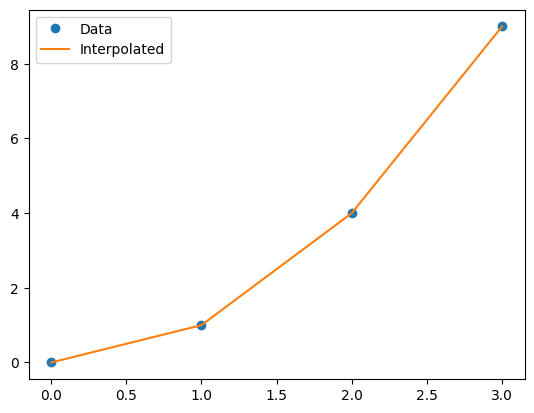

In [16]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 4, 9])
f = interp1d(x, y, kind='linear')

x_new = np.linspace(0, 3, 10)
y_new = f(x_new)

plt.plot(x, y, 'o', label='Data')
plt.plot(x_new, y_new, '-', label='Interpolated')
plt.legend(); plt.show()


## Universal Compatibility Between Functions.

- Shared Data Structures (ndarray): Both NumPy and SciPy use the ndarray as the standard format, enabling seamless communication between functions in both libraries without conversions.

- Interchangeable Input/Output: Functions from SciPy and NumPy can often accept and return each other's outputs, meaning you can pass a NumPy-generated array directly into a SciPy function and vice versa.

- Composable Operations: Because of this compatibility, complex workflows can be built by chaining NumPy and SciPy operations, such as using NumPy for generating data and SciPy for solving equations.

- Consistent Behavior: Since both libraries follow broadcasting, indexing, and array-shape rules similarly, functions behave consistently across contexts, making code easier to write and debug.

- Efficiency & Performance: This compatibility avoids redundant memory operations and conversions, helping maintain performance in scientific computing tasks.



## Example 1: NumPy Array in SciPy Linear Algebra.


- NumPy Arrays are used to create matrices (2D arrays) that represent numerical data.

- These matrices are input to SciPy’s linear algebra functions for advanced mathematical operations.

- SciPy’s scipy.linalg module provides tools like matrix multiplication, inversion, eigenvalues, etc.

- With NumPy, you define matrices; with SciPy, you operate on them.

- This combination is used in solving equations, transformations, and system modeling.

- Example: Solve the equation Ax = b, where A is a matrix and b is a vector.

- Instead of manually solving, we use scipy.linalg.solve() to get x.

- You can calculate determinants with scipy.linalg.det().

- Eigenvalues and eigenvectors of matrices are useful in machine learning and physics.

- SciPy works on top of NumPy but adds more mathematical power.

- This method ensures accurate, fast, and scalable numerical solutions.

- NumPy and SciPy together form a strong backbone of scientific computation in Python.

- Matrix Equation : A.x = b.

- Matrix Inverse  : A^-1 . A = I.

- Determinant(for 2x2)  : det(A)=ad−bc.

- Eigenvalue Equation  : A⋅v=λ⋅v, where 𝜆 is Eigenvalue and v is Eigenvector.




In [18]:
import numpy as np
from scipy import linalg

# 1. Define matrix using NumPy
A = np.array([[3, 1], [1, 2]])

# 2. Inverse of matrix using SciPy
A_inv = linalg.inv(A)
print("Inverse of A:\n", A_inv)

# 3. Matrix multiplication
I = A @ A_inv
print("A * A_inv (should be identity):\n", I)

# 4. Determinant
det = linalg.det(A)
print("Determinant of A:", det)

# 5. Solve Ax = b
b = np.array([9, 8])
x = linalg.solve(A, b)
print("Solution x to Ax = b:", x)

# 6. Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = linalg.eig(A)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)


Inverse of A:
 [[ 0.4 -0.2]
 [-0.2  0.6]]
A * A_inv (should be identity):
 [[1. 0.]
 [0. 1.]]
Determinant of A: 5.0
Solution x to Ax = b: [2. 3.]
Eigenvalues: [3.61803399+0.j 1.38196601+0.j]
Eigenvectors:
 [[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]


## Example 2: NumPy Array in SciPy Optimization.

- NumPy Arrays hold input data or initial guesses for optimization problems.

- SciPy's optimize module is used to minimize or maximize mathematical functions.

- A NumPy Array is passed as the initial guess to scipy.optimize.minimize().

- The function to be optimized must take a NumPy array as input and return a scalar.

- Optimization algorithms like Nelder-Mead, BFGS, etc., search for a value where the function is minimized.

- You can optimize complex functions such as cost, distance, error, or profit.

- The output of optimization is also a NumPy array – the best-fit values.

- NumPy arrays ensure vectorized operations, making optimization faster.

- This technique is used in machine learning, physics, and engineering models.

- You can include constraints, bounds, and Jacobians using additional parameters.

- Multiple Variables can be optimized together, packed into a NumPy array.

- It's a powerful combination: NumPy stores the data, SciPy optimizes it.

- Objective Function    :   f(x,  y) = (x - 3)^2  + (y + 2)^2.

- Optimization Problem      : min f(x), where x belongs to Real Numbers.





In [1]:
import numpy as np
from scipy.optimize import minimize

# 1. Define function to minimize
def func(x):
    return (x[0] - 3)**2 + (x[1] + 2)**2

# 2. Initial guess using NumPy array
x0 = np.array([0, 0])

# 3. Perform optimization
res = minimize(func, x0, method='Nelder-Mead')

# 4. Print results
print("Optimized values:", res.x)
print("Minimum value of function:", res.fun)

# 5. More complex function (Rosenbrock function)
def rosen(x):
    return sum(100.0*(x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

x0 = np.array([1.3, 0.7])
res2 = minimize(rosen, x0, method='BFGS')
print("Optimized (Rosenbrock):", res2.x)



Optimized values: [ 2.99998927 -1.99998758]
Minimum value of function: 2.6951431267951165e-10
Optimized (Rosenbrock): [0.99999552 0.99999102]


## Example 3: SciPy Output Passed to NumPy Sum.


- SciPy functions often return outputs like arrays, tuples, or objects.

- These outputs can be used directly in NumPy functions for further processing.

- For example, you might integrate a function with scipy.integrate.quad() and then sum multiple results using numpy.sum().

- This is useful when performing multiple operations and needing to aggregate the results.

- SciPy’s output can be a scalar or array depending on the function (e.g., FFT, filtering, integration).

- NumPy treats SciPy's output as regular data since SciPy is built on top of NumPy.

- This enables chaining operations: output from one step is input to another.

- This pattern is common in scientific computing, signal processing, and simulations.

- It improves code efficiency, modularity, and readability.

- NumPy's vectorized functions like np.sum, np.mean, np.std work well with SciPy outputs.

- No need for Loops – just collect results and apply a NumPy reduction function.

- It reflects tight integration between NumPy (data) and SciPy (operations).

- Fourier Transform Magnitude     :  modulusF(x) = sqrt(Re^2 + Im^2).

In [2]:
import numpy as np
from scipy.integrate import quad

# 1. Define multiple functions
def f1(x): return x
def f2(x): return x**2
def f3(x): return np.sin(x)

# 2. Integrate using SciPy
res1, _ = quad(f1, 0, 1)
res2, _ = quad(f2, 0, 1)
res3, _ = quad(f3, 0, np.pi)

# 3. Collect results in NumPy array
results = np.array([res1, res2, res3])

# 4. Use NumPy sum on SciPy output
total = np.sum(results)
print("Total sum of integrations:", total)



Total sum of integrations: 2.8333333333333335


## Example 4: NumPy Slice and SciPy Median Filter.


- NumPy slicing is used to extract specific parts of an array, like rows, columns, or submatrices.

- A slice creates a view, not a copy, meaning it reflects changes to the original array.

- Slicing allows for easy manipulation of array segments — e.g., array[1:4] gives 2nd to 4th elements.

- SciPy's median filter is used for noise reduction in data or images, replacing each value with the median of its neighborhood.

- You typically slice the data with NumPy and then apply a SciPy filter on the relevant portion.

- This combo is very efficient in data cleaning, image processing, and signal smoothing.

- Median filtering helps preserve edges in images better than mean filtering.

- You can apply slicing before or after filtering, depending on which region you want to work on.

- This method is especially used in image denoising, edge-preserving filters, and medical imaging.

- The slice-view avoids memory overhead, while the filter applies statistical noise removal.

- Median filter is non-linear, unlike mean (average) filters.

- Useful in data preprocessing pipelines for machine learning or vision applications.


## Example  : Simple NumPy slice.

In [7]:
import numpy as np
a = np.array([1, 2, 3, 4, 5, 6])
print(a[2:5])  # [3 4 5]


[3 4 5]


## Example 5: NumPy Meshgrid for SciPy Interpolation.

- NumPy Meshgrid is used to create coordinate grids from two or more 1D coordinate arrays — it’s great for creating X-Y grids.

- It transforms two 1D arrays (like x and y axes) into 2D coordinate matrices used in surface or grid-based computations.

- SciPy’s interpolation methods (e.g., scipy.interpolate.griddata, interp2d, or RegularGridInterpolator) use these 2D grids for estimating values at new data points.

- Interpolation fills in missing data or estimates values at non-sampled points, often in 2D space.

- Together, NumPy's meshgrid and SciPy's interpolators are powerful for working with surfaces, contour plots, and real-world spatial data.

- It’s commonly used in scientific computing, weather modeling, surface plotting, and image warping.

- Meshgrids provide a structure over which interpolation can be applied systematically.

- The meshgrid helps convert function evaluation points into a rectangular grid over which interpolation is done.

- Without meshgrid, interpolation functions can’t map X-Y to Z correctly in 2D or 3D.

- Meshgrid coordinates match the shape of the data grid, allowing SciPy to interpolate between values.

- Interpolation includes linear, cubic, and nearest types — used based on accuracy vs. speed trade-offs.

- This combination is useful for visualizations like 3D surfaces, heatmaps, and filled contour plots.



##  Example   : Creating a Meshgrid.


In [9]:
import numpy as np

x = np.linspace(0, 5, 5)
y = np.linspace(0, 5, 5)
X, Y = np.meshgrid(x, y)
print(X)
print(Y)


[[0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]]
[[0.   0.   0.   0.   0.  ]
 [1.25 1.25 1.25 1.25 1.25]
 [2.5  2.5  2.5  2.5  2.5 ]
 [3.75 3.75 3.75 3.75 3.75]
 [5.   5.   5.   5.   5.  ]]


## Broadcasting and Slicing Work in SciPy.

- Broadcasting Overview: Broadcasting allows arrays of different shapes to be used in arithmetic operations. When a smaller array is used with a larger one, SciPy (via NumPy) automatically expands the smaller array to match the larger shape without making physical copies.

- Why Broadcasting Matters: It saves memory and computation time, especially in mathematical operations, image processing, and linear algebra. You avoid writing explicit loops and get faster, cleaner code.

- Slicing in SciPy (via NumPy): Slicing is used to access parts of arrays using syntax like a[start:stop:step]. SciPy leverages NumPy's slicing to access and modify data efficiently without copying it.

- Broadcasting + Slicing = Efficient Vectorization: Using slicing and broadcasting together allows vectorized operations. This means you perform complex matrix and vector operations using fewer lines of code and faster execution.

- Application in SciPy Functions: SciPy functions (e.g., signal, optimize, linalg) rely on these principles for efficient computation. The combination of slicing for access and broadcasting for operation simplifies logic.

## Example 1: Broadcasting a Scalar to a Matrix.


- Broadcasting is a powerful NumPy feature that lets arrays with different shapes work together during arithmetic operations.

- When you add a scalar (single number) to a matrix (2D array), NumPy automatically "stretches" the scalar to match the shape of the matrix.

- This happens without actually copying the scalar into every cell, saving memory and increasing speed.

- You can use scalars with any arithmetic operation: addition, subtraction, multiplication, division, etc.

- This behavior is called “broadcasting”, and it works only if NumPy can align shapes properly.

- Think of broadcasting a scalar like applying the same value across every cell in a matrix.

- For example, A + 5 means add 5 to every element of matrix A.

- This makes code simpler, cleaner, and faster than using loops.

- Broadcasting is handled internally by NumPy using vectorized operations, which are optimized in C.

- It avoids explicit repetition, which helps in working with large data efficiently.

- You don’t need to reshape the scalar; NumPy automatically expands it to fit.

- It works with arrays of any shape: 1D, 2D, 3D, etc., as long as the scalar is compatible.

## Example   : Add scalar to 2D Matrix.

In [6]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = a + 5  # Broadcasting scalar
print(b)

# Explanation: The scalar 5 is broadcast to each element of a, adding 5 without looping. This works due to shape compatibility: scalar (1,) matches (2,2).

[[6 7]
 [8 9]]


## Example 2: Broadcasting a 1D Array to 2D.


- Broadcasting a 1D array to a 2D array means stretching a row or column array to perform operations with a 2D matrix.

- It lets NumPy apply element-wise operations without explicitly reshaping or copying arrays.

- If the shapes are compatible, NumPy will automatically align them.

- A row vector (shape (1, n)) can be broadcast across rows of a 2D array.

- A column vector (shape (n, 1)) can be broadcast across columns of a 2D array.

- This allows you to perform matrix-wide operations using just 1D data.

- It's very useful for normalizing rows/columns, applying weights, or adding biases.

- No loops are needed—just write the math directly.

- NumPy handles this by internally expanding the dimensions to match.

- It’s memory efficient—no repeated copies of the 1D array are created.

- This behavior simplifies code and improves performance.

- It enables operations between arrays of different ranks.

  

## Example    :    Add row vector to all rows of a matrix.

In [5]:
import numpy as np
A = np.array([[1, 2], [3, 4], [5, 6]])
b = np.array([10, 20])
result = A + b
print(result)


[[11 22]
 [13 24]
 [15 26]]


## Example 3: Column-Wise Broadcasting.


- Column-wise broadcasting happens when you apply a 1D column vector to each column of a 2D array.

- This is useful when you want to apply operations like scaling or normalization row by row.

- The 1D array (usually shaped (m,)) is reshaped into a column vector of shape (m, 1).

- NumPy then stretches this column vector across all columns of the 2D array.

- It allows for efficient computation without loops or manual duplication.

- This is often used in machine learning to scale features, apply time decay, or normalize data.

- You don’t have to match full dimensions—just make sure broadcasting rules apply.

- Column-wise broadcasting is memory-efficient—no full copy of the array is made.

- It works well with mathematical expressions like element-wise multiplication and division.

- It can also be used to subtract row means or apply weights row-wise.

- Useful in data preprocessing, signal transformation, and array transformations.

- NumPy does the reshaping and expansion behind the scenes automatically.


## Example : Multiply each row by a different scalar.

In [3]:
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
row_weights = np.array([1, 10, 100]).reshape(-1, 1)
result = A * row_weights
print(result)


[[  1   2   3]
 [ 40  50  60]
 [700 800 900]]


## Example 4: Slicing a Submatrix.


- Slicing a submatrix means extracting a smaller rectangular block from a larger NumPy 2D array (matrix).

- It uses NumPy's slice syntax: [row_start:row_end, col_start:col_end].

- The slice includes the start index but excludes the end index, just like Python lists.

- It gives you a view, not a copy—changing the slice will affect the original matrix (unless explicitly copied).

- It's very memory-efficient, no data is duplicated during slicing.

- Submatrix slicing is used in image processing, scientific computing, and matrix algebra.

- You can also slice rows, columns, or specific blocks using this method.

- Supports flexible combinations like skipping rows or columns using steps: [::2, 1::2].

- Can be combined with conditions to extract meaningful data regions.

- Helps with fast matrix operations without loops or complex indexing.

- Advanced slicing uses NumPy functions like np.ix_() for more control.

- It simplifies manipulating data grids, spatial maps, or datasets in tabular form.

## Example   :  Basic submatrix.

In [6]:
import numpy as np
A = np.arange(1, 17).reshape(4, 4)
print("Original Matrix:\n", A)
sub = A[1:3, 1:3]
print("Submatrix:\n", sub)


Original Matrix:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
Submatrix:
 [[ 6  7]
 [10 11]]


## Example 5: Slicing with Steps.

In [10]:
a = np.arange(10)
print(a[1:9:2])


[1 3 5 7]


## Efficient Memory and Performance.


- Vectorization Saves Time: SciPy, through NumPy arrays, supports vectorized operations, meaning calculations are done over entire arrays at once instead of using Python loops. This drastically reduces execution time by using optimized C under the hood.

- Broadcasting Avoids Memory Copies: Broadcasting allows arithmetic between arrays of different shapes without actually copying data. It virtually reshapes data to match dimensions, reducing memory overhead.

- Slicing is a View, Not a Copy: Array Slicing in SciPy (via NumPy) returns views, not copies. Modifying a slice directly affects the original array, which improves performance and saves memory.

- Built-in Functions Are Optimized: SciPy provides mathematical and linear algebra functions (e.g. scipy.linalg, scipy.sparse) that are highly optimized. These functions run faster and use less memory compared to manual implementations.

- Sparse Matrices Save Huge Space: SciPy's sparse module enables working with large, mostly-zero matrices without storing zero values. This leads to massive memory savings in scientific computing.

## Example 1: Vectorized Addition vs. Loop.

- Vectorized Addition is a fast, efficient way to Add Elements of Arrays using NumPy Functions directly.

- Loop-based addition manually processes elements one by one using for loops.

-  Vectorized operations are written in fewer lines and are more readable.

-  Vectorized addition uses optimized low-level C code behind NumPy – so it runs faster.

-  Loops are slower in Python, especially with Large Arrays, because they Execute one SElement-wise Addition

-  Both vectorized addition and loops perform element-wise addition, meaning they add numbers at the same positions in two arrays or lists.tep at a time.
   
-  Vectorized code is more Pythonic – it takes advantage of Python’s high-level features.

-  Looping gives more control if complex logic is needed per element.

-  Both give the same result, but speed and simplicity differ.

-  In Machine Learning, data science, and scientific computing, vectorization is preferred.

-  NumPy and SciPy Libraries encourage Vectorization over Loops.

-  Element-wise Addition : Both Vectorized Addition and Loops perform Element-Wise Addition, meaning they Add Numbers at the same Positions in two Arrays or Lists. Example: [1, 2, 3] + [4, 5, 6] = [1+4, 2+5, 3+6] = [5, 7, 9].

-  Vectors and Arrays : Mathematically, Arrays are Just Vectors — ordered Lists of Numbers. Vectorized Addition adds these vectors directly without using explicit iteration.

- Loop as Repeated Scalar Addition  : A loop performs addition like: c[0] = a[0] + b[0], c[1] = a[1] + b[1], and so on.

- Vectorized = Linear Algebra Style  :  Vectorized addition follows the style used in linear algebra, where vectors and matrices are operated on as Complete Blocks. This matches how Math is written: C = A + B.

- Same Shape Rule(Dimensions Must Match) : You can only add vectors/arrays of the same size (e.g., two 1D arrays with 3 elements). Mathematically, this is like saying: If A and B are n-dimensional vectors, A + B is only valid when length(A) = length(B).

- Broadcasting (Special Case in Vectorized Ops)  : When shapes don’t match, NumPy can still add them using a concept called broadcasting — it repeats smaller arrays automatically. Example: adding [1, 2, 3] to [[1], [2], [3]] results in a 3x3 array.

- Associative and Commutative Properties  :  Both Vectorized and Loop-based Addition follow basic Math rules:
Associative: (a + b) + c = a + (b + c).
Commutative: a + b = b + a.






In [14]:
import numpy as np
a = np.arange(100)
b = np.arange(100)
c = a + b # Fast Vectorized Addition.
print(c)

# Explanation: This adds two large arrays in one step using vectorization. Avoids slow Python for loops, uses optimized C routines under the hood.

[  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186 188 190 192 194 196 198]


## Example 2: Broadcasting Without Copies.

- Broadcasting means NumPy lets you do operations between arrays of different shapes as if they were the same size.

- Without Copies means NumPy does not actually duplicate the smaller array in memory — it behaves as if the data were stretched or repeated, but efficiently.

- This makes operations fast and memory-efficient, especially when working with large datasets or arrays.

- Broadcasting lets you do operations like adding a vector to each row of a matrix, without writing a loop.

- NumPy internally adjusts the shapes so they match during computation, without allocating extra memory.

- This is possible by using views, strides, or just applying the logic without expanding the array.

- The smaller array is conceptually stretched to match the shape of the larger one without making actual copies.

- It works best when one array has shape (m, 1) or (1, n) — where dimensions of size 1 can be broadcasted.

- You avoid wasting memory that would happen if you repeated the smaller array manually.

- Operations like addition, multiplication, and comparison work element-by-element using the broadcasted shapes.

- Broadcasting is safe, clean, and avoids writing slow Python loops.

- This method is vectorized — making your code faster and more like mathematical notation.

- Element-wise Operations: Operations are applied between elements at matching positions, like a[i][j] + b[i][j].

- Dimension Expansion: If arrays don’t have the same number of dimensions, NumPy automatically adds dimensions (like turning a 1D into 2D) for matching.

- Matching Rule: Dimensions must either be equal or one of them must be 1.

- Implicit Tiling: It’s like the smaller array is repeated to match the larger one, but only logically, not physically.

- Shape Alignment: Arrays are reshaped or virtually expanded so operations can proceed as if they had compatible shapes.

- Linear Algebra Compatibility: Matches operations like broadcasting a vector in matrix-vector multiplication.

- Avoids Redundant Storage: Instead of storing [5, 5, 5], NumPy keeps 5 once and knows it repeats — this is space-efficient.

- Strides: Under the hood, NumPy uses stride tricks to map the same memory location multiple times for broadcasting.

- Vector and Matrix Math: Broadcasted operations mimic traditional vector-matrix arithmetic used in math textbooks.

- Efficiency: No copying means better performance, especially for large datasets.

- Slicing and Views: Broadcasted arrays can interact with views or slices without allocating new memory.

- Generalized Dot Products: Enables higher-dimensional tensor operations without reshaping arrays manually.


In [15]:
a = np.ones((3, 3))
b = np.array([1, 2, 3])
print(a * b)  # Broadcasting b across rows.

# Explanation: No need to replicate b. SciPy internally broadcasts it, multiplying it efficiently with each row of a.


[[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]


## Example 3: Slice View (No Memory Copy).

- A slice View in NumPy means you access part of an array without making a separate copy in memory.

- The sliced part is a "view" of the original array — changes to the slice also change the original.

- This is memory efficient, especially when working with large arrays, because it avoids duplication.

- You use simple slicing like a[1:4] to get a view of some elements.

- NumPy does this using pointers and strides — it doesn’t duplicate data, just refers to the same memory.

- Views are created when you slice using :` (colon) or with advanced indexing.

- It's much faster than copying because no data is actually moved or reallocated.

- If you modify a slice, you are modifying the original array too — this is different from a full copy.

- You can create copies explicitly using .copy() if you want to avoid changing the original.

- Most functions in NumPy are optimized to return views where possible.

- This idea supports vectorized operations, which are fast and efficient.

- Understanding views helps avoid bugs when your changes unexpectedly affect other arrays.

  

In [16]:
a = np.array([10, 20, 30, 40, 50])
b = a[1:4]
b[0] = 999
print(a)  # Output: [10 999 30 40 50]

# Explanation: Slice b is a view of a, not a separate array. Changing b modifies the original—saves memory.

[ 10 999  30  40  50]


## Example 4: Sparse Matrix for Space Efficiency.

In [17]:
from scipy.sparse import csr_matrix
dense = np.zeros((1000, 1000))
dense[0, 0] = 10
sparse = csr_matrix(dense)
print(sparse)

# Explanation: Storing a 1000x1000 matrix with mostly zeros as sparse saves >99% of memory. Only non-zero values are stored.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1000, 1000)>
  Coords	Values
  (0, 0)	10.0


## Example 5: In-place Operations.

In [18]:
a = np.array([1, 2, 3])
a *= 2  # In-place multiplication
print(a)

# Explanation: No New Array is created. The Original Memory of a is Reused—Memory-efficient and Fast.

[2 4 6]


## Shared Mathematical Constants and Functions.

- Access to Scientific Constants: SciPy offers a wide range of predefined physical and mathematical constants via scipy.constants. These include values like π (pi), Planck's constant, speed of light, etc., which are accurate and ready to use for scientific computations.

- Mathematical Functions for Engineering & Physics: SciPy includes functions for computing factorials, logarithms, permutations, combinations, and gamma functions that are optimized for scientific accuracy and performance.

- Unit Conversion Tools: The scipy.constants module also provides conversion factors between different units of measurement, such as converting from atmospheres to Pascals or from miles to kilometers.

- High Precision and Predefined Values: These constants and functions are predefined, which reduces errors from manual input and ensures consistency across scientific computations, useful in research and engineering.

- Grouped and Searchable: Constants are categorized (e.g., electromagnetic, thermodynamic, atomic units) and easily accessible. You can even search for them by keyword using built-in functions.

## Example 1: Accessing π.

- π (pi) is a mathematical constant approximately equal to 3.14159, used in many calculations involving circles and trigonometry.

- In Python, you don’t have to type 3.14 manually — you can access the accurate value of π using libraries.

- The most common way is using math.pi from the built-in math module.

- Another way is numpy.pi if you are already using NumPy for scientific computing.

- These libraries give a precise and reliable value of π for any calculations.

- It is used in formulas like area of a circle (πr²) or circumference (2πr).

- Accessing π helps avoid errors that come from using rounded or incorrect values.

- π is also used in trigonometry functions, like sine or cosine.

- You can access π with just one line of code, no need to define it yourself.

- Using math.pi or np.pi keeps your code cleaner and more readable.

- You can also use π in integration, Fourier transforms, or simulations.

- Accessing π ensures you are working with a standard and consistent value across your code.

## Example: Using math.pi

In [18]:
import math
print("Value of pi:", math.pi)


Value of pi: 3.141592653589793


## Example:  Area of a circle using math.pi.

In [19]:
import math
radius = 5
area = math.pi * radius ** 2
print("Area of circle:", area)


Area of circle: 78.53981633974483


## Example 2: Speed of Light.

- Speed of Light is a universal constant used in physics and science.

- It is the speed at which light travels in a vacuum.

- The exact value is 299,792,458 meters per second (m/s).

- It's commonly represented by the symbol c in formulas.

- It's used in Einstein’s famous equation: E = mc².

- It's critical in fields like astronomy, physics, and telecommunications.

- It helps calculate how far light travels over time or through space.

- It’s used to compute light-years, the distance light travels in a year.

- Python provides the speed of light in the SciPy constants module.

- You can import it using: from scipy.constants import c.

- This constant is also helpful in relativity, quantum mechanics, and laser tech.

- It makes calculations involving energy, mass, and distance easier and more accurate.

## Example:  Import and print the speed of light.

In [20]:
from scipy.constants import c
print("Speed of light in m/s:", c)


Speed of light in m/s: 299792458.0


## Example: Calculate distance light travels in 1 second.

In [21]:
from scipy.constants import c
time_seconds = 1
distance = c * time_seconds
print("Light travels in 1 second:", distance, "meters")


Light travels in 1 second: 299792458.0 meters


## Example 3: Planck’s Constant.

- Planck’s Constant is a fundamental constant used in quantum physics.

- It describes how energy and frequency of a particle (like a photon) are related.

- It’s used in the equation E = h × f, where: E = Energy, h = Planck’s Constant, f = Frequency.

- he constant’s value is about 6.62607015 × 10⁻³⁴ Joule·seconds (J·s).

- It shows that energy comes in tiny packets, not continuous flows.

- It’s critical in understanding light, atoms, and particles at the smallest scales.

- It’s used in formulas like photoelectric effect and blackbody radiation.

- It helps explain why electrons exist only in discrete energy levels in atoms.

- It’s essential in fields like quantum mechanics, nanotechnology, and spectroscopy.

- In Python, you can access it from SciPy using: from scipy.constants import h

- There’s also a version called reduced Planck’s constant (ħ = h / (2π)).


## Example: Import and print Planck’s Constant.

In [16]:
from scipy.constants import h
print("Planck's constant:", h, "Joule·seconds")


Planck's constant: 6.62607015e-34 Joule·seconds


## Example: Calculate energy of a photon with given frequency.

In [17]:
from scipy.constants import h
frequency = 5e14  # Hz (e.g., visible light)
energy = h * frequency
print("Energy of photon:", energy, "Joules")


Energy of photon: 3.313035075e-19 Joules


## Example 4: Boltzmann Constant.

- Boltzmann Constant (k or kB) relates the average energy of particles in a gas to the temperature of the gas.

- Its value is about 1.380649 × 10⁻²³ J/K (Joules per Kelvin).

- It is used in thermodynamics and statistical mechanics.

- It helps calculate how thermal energy affects atoms and molecules.

- It appears in formulas like KE = (3/2)·k·T, which gives average kinetic energy.

- It connects temperature to energy at the atomic/molecular level.

- It’s crucial for understanding gas pressure, entropy, and heat capacity.

- In Python, you can import it using from scipy.constants import k.

## Example: Import and print Boltzmann Constant.

In [14]:
from scipy.constants import k
print("Boltzmann Constant:", k, "Joules per Kelvin")


Boltzmann Constant: 1.380649e-23 Joules per Kelvin


## Example: Calculate average kinetic energy at room temperature (T = 300 K).

In [15]:
from scipy.constants import k
T = 300  # Kelvin
KE = (3/2) * k * T
print("Average kinetic energy of a gas molecule:", KE, "Joules")


Average kinetic energy of a gas molecule: 6.2129205000000004e-21 Joules


## Example 5: Converting Miles to Kilometers.

- Miles and kilometers are units to measure distance.

- 1 mile is equal to 1.60934 kilometers (approx.).

- We convert miles to kilometers by multiplying the number of miles by 1.60934.

- This is useful when working with different unit systems, like US (miles) vs. most of the world (kilometers).

- Conversion is helpful in geography, travel, mapping, and science.

- Python allows you to do this with a simple arithmetic operation.

- For more accuracy and scientific work, we can use scipy.constants.

- scipy.constants.mile gives the value of 1 mile in meters.

- To convert to kilometers, divide meters by 1000.

- This conversion helps in data analysis, like converting GPS data or speed records.








In [25]:
from scipy.constants import mile, kilo
print("Miles in kilometers:", mile / kilo)

# Explanation: Unit conversion becomes precise and convenient using predefined factors.


Miles in kilometers: 1.6093439999999999


## Example: Simple manual Conversion using Multiplication.

In [11]:
miles = 5
kilometers = miles * 1.60934
print(f"{miles} miles is equal to {kilometers} kilometers")


5 miles is equal to 8.0467 kilometers


## Example: Convert a list of distances.

In [12]:
mile_list = [1, 5, 10, 20]
km_list = [mile * 1.60934 for mile in mile_list]
print("Kilometers:", km_list)


Kilometers: [1.60934, 8.0467, 16.0934, 32.1868]


## Example: Function to convert miles to kilometers.

In [13]:
def miles_to_km(miles):
    return miles * 1.60934

print(miles_to_km(3))  # Output: 4.82802


4.82802


## Matrix Operations – Extended in SciPy.

- Matrix Inversion: SciPy provides a reliable and optimized method to find the inverse of a square matrix using scipy.linalg.inv(). It checks for numerical stability and raises an error if the matrix is singular (non-invertible).

- Determinant Calculation: Using scipy.linalg.det(), you can calculate the determinant of a square matrix, useful in solving equations and determining invertibility.

- Solving Linear Systems: scipy.linalg.solve() solves equations of the form Ax = b efficiently without explicitly computing the inverse, reducing computation time and error.

- Matrix Decompositions: SciPy supports LU, QR, Cholesky, and SVD decomposition methods. These break down matrices for easier computation in optimization and statistics.

## Example 1: Matrix Inversion.

- A matrix inversion is the process of finding the inverse of a square matrix.

- The inverse of a matrix A is another matrix A⁻¹ such that: A.A^-1 = I, where I is the Identity Matrix.

- Only square matrices (same number of rows and columns) can be inverted.

- Not all square matrices have an inverse. A matrix must be non-singular (i.e., its determinant ≠ 0).

- The Inverse is useful in solving systems of linear equations, like Ax = b.

- Instead of solving equations directly, you can multiply both sides by A⁻¹ to get: x = A^-1 . b.

- Matrix inversion is used in computer graphics, engineering, physics, and machine learning.

- In Python, matrix inversion is commonly done using NumPy or SciPy.

- The function np.linalg.inv() or scipy.linalg.inv() is typically used.

- For better performance or larger matrices, use SciPy for numerical stability.

- Matrix inversion is a computationally expensive operation.

- If a matrix is ill-conditioned, its inverse can be inaccurate, so alternatives like LU decomposition are sometimes used.

In [26]:
from scipy.linalg import inv
import numpy as np

A = np.array([[2, 1], [5, 3]])
A_inv = inv(A)
print("Inverse of A:\n", A_inv)


Inverse of A:
 [[ 3. -1.]
 [-5.  2.]]


## Example: Inverting a 2×2 Matrix using NumPy.

In [7]:
import numpy as np

A = np.array([[4, 7],
              [2, 6]])

A_inv = np.linalg.inv(A)
print("Inverse of A:\n", A_inv)


Inverse of A:
 [[ 0.6 -0.7]
 [-0.2  0.4]]


## Example: Check if A × A⁻¹ = Identity.

In [9]:
identity = np.dot(A, A_inv)
print("A * A_inv:\n", identity)

A * A_inv:
 [[ 1.00000000e+00 -1.11022302e-16]
 [-1.11022302e-16  1.00000000e+00]]


## Example: Using SciPy for Matrix Inversion. 

In [10]:
from scipy.linalg import inv

B = np.array([[1, 2],
              [3, 4]])

B_inv = inv(B)
print("Inverse of B:\n", B_inv)


Inverse of B:
 [[-2.   1. ]
 [ 1.5 -0.5]]


## Example 2: Matrix Determinant.

- The determinant is a single number calculated from a square matrix (same number of rows and columns).

- It helps us understand the properties of a matrix, such as whether it is invertible.

- If the determinant is 0, the matrix is singular (non-invertible).

   For 2×2 matrices, the determinant is: det([𝑎  b
c d]) = ad−bc.

- Determinants are used in solving systems of linear equations, matrix inversion, and calculating area/volume.

- It can also indicate how a matrix transformation affects scaling of shapes.

- A positive determinant means the orientation is preserved; a negative one means it’s flipped.

- A larger absolute value of a determinant means greater scaling.

- Python libraries like NumPy and SciPy can calculate it using np.linalg.det() or scipy.linalg.det().

- The determinant of an identity matrix is always 1.

- Determinants are used in geometry, physics, computer graphics, and more.

- They’re essential in linear algebra to understand matrix behavior.

In [27]:
from scipy.linalg import det

A = np.array([[4, 6], [3, 8]])
print("Determinant of A:", det(A))


Determinant of A: 13.999999999999998


## Example:  Determinant of a 2×2 Matrix.

In [5]:
import numpy as np

A = np.array([[4, 2],
              [3, 1]])

det_A = np.linalg.det(A)
print("Determinant of A:", det_A)


Determinant of A: -2.0


## Example: Determinant of a 3×3 Matrix.

In [6]:
B = np.array([[1, 2, 3],
              [0, 4, 5],
              [1, 0, 6]])

det_B = np.linalg.det(B)
print("Determinant of B:", det_B)


Determinant of B: 22.000000000000004


# Example 3: Solve Linear System.

- A Linear System consists of linear equations like Ax = b, where A is a matrix, x is unknowns, and b is known values.

- Solving means finding the values of x that make all equations true.

- It’s commonly used in science, economics, engineering, etc.

- The matrix form makes it easier to handle large systems.

- If the system has a unique solution, it’s called consistent.

- If there are no solutions, it's inconsistent.

- If there are infinitely many solutions, it's underdetermined.

- numpy.linalg.solve() is used when A is square and invertible.

- scipy.linalg.solve() works similarly with high performance.

- Solving avoids manually inverting A which is costly and less accurate.

- A must be non-singular (det(A) ≠ 0) to get a solution.



In [28]:
from scipy.linalg import solve

A = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
x = solve(A, b)
print("Solution of Ax = b:", x)


Solution of Ax = b: [2. 3.]


In [4]:
import numpy as np
from scipy.linalg import solve

# Example 1: Simple 2x2 system
A = np.array([[2, 1],
              [1, 3]])
b = np.array([8, 13])
x = solve(A, b)
print("Solution:", x)

# Example 2: Using numpy.linalg.solve
x2 = np.linalg.solve(A, b)
print("Numpy solution:", x2)

# Example 3: Solve 3x3 system
A3 = np.array([[1, 2, 3],
               [0, 1, 4],
               [5, 6, 0]])
b3 = np.array([14, 13, 23])
x3 = solve(A3, b3)
print("3x3 Solution:", x3)

# Example 4: Check if the solution works
print("Check Ax ≈ b:", np.allclose(A @ x, b))

# Example 5: Singular system (error expected)
try:
    A_bad = np.array([[1, 2], [2, 4]])
    b_bad = np.array([3, 6])
    solve(A_bad, b_bad)
except Exception as e:
    print("Error:", e)


Solution: [2.2 3.6]
Numpy solution: [2.2 3.6]
3x3 Solution: [13. -7.  5.]
Check Ax ≈ b: True
Error: Matrix is singular.


## Example 4: LU Decomposition.

- LU Decomposition splits matrix A into L (Lower) and U (Upper) matrices.

- It helps solve linear systems more efficiently than using inverse.

- L has 1s on the diagonal and values below it; U has values above diagonal.

- You can solve Ax = b by solving Ly = b then Ux = y.

- Often used in numerical analysis for stability.

- LU is mainly used with square matrices.

- Can speed up solving multiple systems with same A and different b.

- scipy.linalg.lu() returns L, U, and permutation matrix P.

- LU decomposition helps in computing determinant and matrix inversion.

- Useful for matrix factorization and engineering applications.

- Faster than computing inverse manually.

- Must check if the matrix is non-singular for LU to work properly.

In [29]:
from scipy.linalg import lu

A = np.array([[3, 4], [1, 2]])
P, L, U = lu(A)
print("L:\n", L, "\nU:\n", U)


L:
 [[1.         0.        ]
 [0.33333333 1.        ]] 
U:
 [[3.         4.        ]
 [0.         0.66666667]]


## Example 5: QR Decomposition.

- QR Decomposition splits matrix A into Q (orthogonal) and R (upper-triangular).

- Q is such that Q.T @ Q = I (orthogonal), and R is triangular.

- Used in least squares problems and eigenvalue calculations.

- It is numerically stable, especially for large or overdetermined systems.

- A = QR can be used to solve Ax = b.

- scipy.linalg.qr() is used to perform the decomposition.

- Q helps rotate space; R helps scale it.

- Often used in machine learning and data regression.

- Can be more stable than LU when A is not square.

- QR is also useful for orthonormal basis generation.

- Orthogonality of Q means fewer numerical errors.

- numpy.linalg.qr() is also available.


In [3]:
from scipy.linalg import qr
import numpy as np

# Step 1: Define the matrix A (3x2) and vector b (3,)
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])
b = np.array([1, 2, 3])

# Step 2: QR decomposition
Q, R = qr(A)

# Step 3: Solve least-squares problem using QR
# Compute Q.T @ b
y = Q.T @ b

# Solve R @ x = y using np.linalg.lstsq (because R is 2x2, y is length 2)
x = np.linalg.lstsq(R, y, rcond=None)[0]

# Step 4: Print the solution
print("Least-squares QR solution x:", x)

# Step 5: Reconstruct A from Q and R (optional)
A_reconstructed = Q @ R
print("Reconstructed A:\n", A_reconstructed)




Least-squares QR solution x: [3.13271901e-16 5.00000000e-01]
Reconstructed A:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]
